# Unidad II · Procesamiento y extracción de características
## Seis ejemplos prácticos en Python

**Visión por Computadora · Maestría en Ciencia de Datos e IA · UPN**
Prof. Luis Torrejón

Cada ejemplo corresponde a un bloque del temario. Todo se ejecuta en Google Colab sin descargar nada: se usan las imágenes incluidas en `scikit-image`, el dataset de dígitos de `scikit-learn` y escenas sintéticas con **verdad de terreno conocida**, lo que permite medir con métricas y no solo mirar.

| # | Bloque | Qué se demuestra |
|---|---|---|
| 1 | Bordes y contornos | Gradiente (magnitud y orientación), Sobel vs Prewitt vs Canny con F1 frente al ruido, Canny implementado paso a paso, bordes de sombra, métricas de forma y un clasificador geométrico de piezas con calibración en milímetros |
| 2 | HOG y descriptores locales | HOG implementado a mano y verificado contra scikit-image, tamaño del vector, robustez a la iluminación y sensibilidad a la rotación, LBP para texturas, esquinas de Harris y Shi-Tomasi |
| 3 | Segmentación | Otsu implementado a mano, umbral global vs adaptativo con F1, multi-Otsu, K-means en distintos espacios de características, watershed para separar objetos que se tocan |
| 4 | SIFT, SURF, ORB | Detección y descriptores, emparejamiento con verdad de terreno (homografía conocida), prueba de razón y RANSAC, curvas de robustez a rotación y escala, par estéreo real |
| 5 | Reconocimiento de patrones | Rostro vs no rostro con HOG/LBP + SVM/kNN/RF, Viola-Jones, detector por ventana deslizante con NMS y AP, reconocimiento por plantilla vs por puntos clave |
| 6 | OpenCV + scikit-image | Trampas de interoperabilidad, equivalencias y tiempos, pipeline reproducible con prueba de robustez |

In [ ]:
# Comentario indicador del paso 1 de aprovisionamiento de infraestructura de software.
# Comando Conda para crear un entorno virtual aislado denominado `upnvc` fijando Python en versión `3.11.15`, garantizando compatibilidad binaria con ruedas de C++.
# Activa el entorno virtual `upnvc` modificando las variables del sistema `PATH` para aislar las dependencias del intérprete global.

# Indica la instalación del framework de tensores PyTorch compatible con el runtime CUDA versión 11.8.
# Descarga los binarios precompilados de PyTorch y TorchVision vinculados a los controladores NVIDIA cu118 para aceleración hardware.
# Comentario que delimita la opción de ejecución exclusiva sobre procesador central (CPU).

# Instala los paquetes de PyTorch optimizados para CPU desde el repositorio oficial de ruedas ligeras.
# Comentario del paso 3 para instalación de la pila científica y de visión por computadora.
# Instala las dependencias maestras fijando `opencv-contrib-python==4.10.0.84` (que incluye submódulos avanzados como `xfeatures2d`), NumPy para álgebra tensorial, Pandas para tablas de métricas, scikit-learn para machine learning, Matplotlib para graficación, scikit-image para procesamiento de imágenes e ipykernel para ejecución interactiva en Jupyter.

# Paso 3: Fija la instalación de librerías en sus versiones estables de producción.
# Comando pip para instalar opencv-contrib, numpy, scikit-image y scipy con versiones fijadas.

In [1]:
# Nota que recuerda que Google Colab preinstala la mayoría de dependencias del curso.
import time, json, platform  # Módulos estándar de Python: `time` para cronometraje de alta precisión (`perf_counter`), `json` para serialización de metadatos y `platform` para inspección del sistema operativo.
import numpy as np  # Importa NumPy bajo el alias estándar `np` para cómputo matricial vectorial y operaciones en arrays continuos en C.
import pandas as pd  # Importa Pandas bajo el alias `pd` para estructurar datos tabulares, series estadísticas y formateo de resultados numéricos.
import cv2  # Importa OpenCV (`Open Source Computer Vision Library`), motor en C++ de alto rendimiento para visión artificial en tiempo real.
import matplotlib.pyplot as plt  # Importa la interfaz pyplot de Matplotlib para renderizado de figuras, mapas de color, histogramas y cuadrículas visuales.
import skimage  # Importa el paquete raíz de `scikit-image`, biblioteca científica para procesamiento de imágenes en Python sobre NumPy.
from skimage import data, feature, filters, measure, segmentation, morphology, color, util, transform, draw  # Importa los submódulos especializados de skimage: datasets estándar (`data`), extracción de características (`feature`), filtros lineales y no lineales (`filters`), propiedades geométricas y contornos (`measure`), segmentación (`segmentation`), operadores morfológicos (`morphology`), espacios de color (`color`), utilidades de tipos (`util`), transformaciones geométricas (`transform`) y dibujo analítico (`draw`).
from scipy import ndimage as ndi  # Importa el submódulo `ndimage` de SciPy bajo el alias `ndi`, optimizado para filtros multidimensionales, transformadas de distancia y etiquetado morfológico.

np.random.seed(0)  # Ajusta la resolución de renderizado de Matplotlib a 110 DPI (puntos por pulgada) para figuras nítidas sin sobrecargar memoria gráfica.
plt.rcParams["figure.dpi"] = 110  # Configura Pandas para que imprima hasta 140 caracteres de ancho en consola antes de cortar tablas verticalmente.
pd.set_option("display.width", 140)  # Define la función modular para desplegar colecciones de imágenes en rejillas de subfiguras con configuración automática de filas y columnas.

def mostrar(imgs, titulos=None, cols=None, tam=3.2, cmap="gray", vmin=None, vmax=None):  # Calcula el número de imágenes n, establece el número de columnas deseadas y determina las filas requeridas mediante el techo entero (`ceil`).
    """Cuadrícula de imágenes. Las uint8 en gris se muestran en [0, 255] sin reescalar."""  # Crea el lienzo principal de Matplotlib con dimensiones proporcionales al número de cuadrantes (`tam * cols, tam * filas`).
    n = len(imgs); cols = cols or n; filas = int(np.ceil(n / cols))  # Asegura que el arreglo de ejes sea unidimensional para permitir indexación plana lineal (`axes[i]`) independientemente de si hay 1 o muchas subfiguras.
    fig, axes = plt.subplots(filas, cols, figsize=(tam * cols, tam * filas))  # Oculta las marcas numéricas de coordenadas de todos los cuadrantes para lograr una presentación visual limpia.
    axes = np.atleast_1d(axes).ravel()  # Itera indexando cada imagen de la lista proporcionada.
    for ax in axes: ax.axis("off")  # Evalúa si la imagen es bidimensional (monocromática / escala de grises de 1 canal).
    for i, img in enumerate(imgs):  # Inicializa los límites de visualización con los argumentos explícitos provistos.
        if img.ndim == 2:  # Si la imagen es entera de 8 bits (`uint8`) y no se forzó escala, fija estrictamente el rango entre 0 y 255.
            lo, hi = vmin, vmax  # Renderiza la imagen bidimensional con el colormap especificado (`gray` por defecto) y límites de intensidad fijados.
            if img.dtype == np.uint8 and lo is None: lo, hi = 0, 255  # Rama para imágenes tridimensionales (RGB multicanal).
            axes[i].imshow(img, cmap=cmap, vmin=lo, vmax=hi)  # Renderiza directamente la imagen a color interpretando los canales como RGB estándar.
        else:  # Asigna el título descriptivo individual al cuadrante si se proporcionó la lista de títulos.
            axes[i].imshow(img)  # Ajusta márgenes automáticamente para evitar colisiones tipográficas y despliega la figura completa.
        if titulos: axes[i].set_title(titulos[i], fontsize=9)  # Define la función métrica de Intersección sobre Unión (IoU / Coeficiente de Jaccard) para evaluar solapamiento entre máscaras binarias.
    plt.tight_layout(); plt.show()  # Convierte ambos arreglos de entrada a máscaras booleanas binarias (True/False).

def iou(a, b):  # Define la función para computar la puntuación armónica F_1 (Dice Coefficient) entre una máscara binaria predicha y la verdad de terreno.
    a, b = a.astype(bool), b.astype(bool)  # Conteo de contingencia: Verdaderos Positivos (ambos True), Falsos Positivos (predijo True pero era False) y Falsos Negativos (era True pero predijo False).
    return (a & b).sum() / max((a | b).sum(), 1)  # Computa la métrica F_1 = \frac{2 \cdot VP}{2 \cdot VP + FP + FN}, media armónica de precisión y sensibilidad.

def f1_mascara(pred, gt):  # Carga la imagen canónica a color de 512x512x3 píxeles (astronauta Eileen Collins).
    tp = (pred & gt).sum(); fp = (pred & ~gt).sum(); fn = (~pred & gt).sum()  # Carga la imagen canónica en escala de grises de 303x384 píxeles con monedas superpuestas sobre fondo oscuro.
    return 2 * tp / max(2 * tp + fp + fn, 1)  # Imprime las versiones activas de las tres bibliotecas principales para verificación de compatibilidad en tiempo de ejecución.

camara     = data.camera()  # Carga la imagen monocromática estándar de prueba 'cameraman' (512x512) de scikit-image.
astronauta = data.astronaut()  # Carga la imagen estándar en color 'astronauta' (Eileen Collins, 512x512x3).
monedas    = data.coins()  # Carga la imagen estándar monocromática de 24 monedas sobre fondo oscuro.
print(f"OpenCV {cv2.__version__} · scikit-image {skimage.__version__} · NumPy {np.__version__}")  # Imprime las versiones en tiempo de ejecución de OpenCV, scikit-image y NumPy para trazabilidad.

OpenCV 4.14.0 · scikit-image 0.25.2 · NumPy 2.1.3


---
# Ejemplo 1 · Detección de bordes y contornos

**Objetivo.** Medir el gradiente, comparar objetivamente los detectores clásicos frente al ruido, entender cada etapa de Canny implementándola, y pasar de bordes a contornos medibles que permitan reconocer piezas solo con geometría.

### 1.1 El gradiente: magnitud y orientación
En la imagen de orientación, el **tono** codifica la dirección del gradiente y el **brillo** su magnitud: el mismo borde tiene color constante a lo largo de su recorrido.

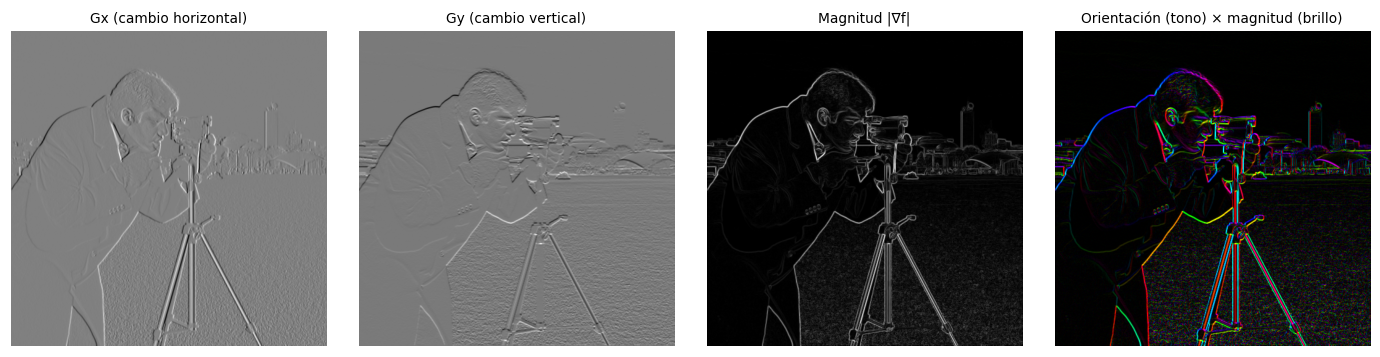

In [2]:
img = camara.astype(np.float32)  # Convierte los enteros `uint8` de la imagen a coma flotante `float32` para evitar desbordamientos aritméticos al calcular derivadas con valores negativos.
kernels = {"Sobel":   np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], np.float32),  # Aplica el operador de Sobel en el eje horizontal (dx=1, dy=0) usando un kernel de 3x 3 con salida en `CV_32F`, computando g_x = \frac{\partial I}{\partial x}.
           "Prewitt": np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], np.float32)}  # Aplica el operador de Sobel en el eje vertical (dx=0, dy=1) usando un kernel de 3x 3 con salida en `CV_32F`, computando g_y = \frac{\partial I}{\partial y}.

gx = cv2.filter2D(img, cv2.CV_32F, kernels["Sobel"])  # Calcula la norma Manhattan L_1: M_{L1} = \
gy = cv2.filter2D(img, cv2.CV_32F, kernels["Sobel"].T)  # Calcula el ángulo de la dirección del gradiente \theta = \arctan\left(\frac{g_y}{g_x}\right) mapeado a grados sexagesimales en el intervalo no signado [0^\circ, 180^\circ).
magnitud = np.hypot(gx, gy)  # Fija una fila de interés analítico (y=150) que cruza el perfil del cuerpo del fotógrafo.
orientacion = np.arctan2(gy, gx)  # Encuentra la coordenada en x del píxel con la mayor magnitud de gradiente a lo largo de la fila seleccionada.

hsv = np.zeros(img.shape + (3,), np.float32)  # Imprime las componentes ortogonales del gradiente en dicho píxel crítico.
hsv[..., 0] = (np.rad2deg(orientacion) % 360)  # Contrasta el valor de la norma euclidiana frente a la norma Manhattan y reporta el ángulo ortogonal al borde físico.
hsv[..., 1] = 1.0  # Llama a la función de visualización para desplegar los 5 mapas espectrales.
hsv[..., 2] = np.clip(magnitud / np.percentile(magnitud, 99), 0, 1)  # gx
orient_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)  # Ajusta la disposición a 5 columnas horizontales con mapa de grises.

mostrar([gx, gy, magnitud, orient_rgb],  # Invoca función mostrar() pasando la lista de tensores: componentes Gx, Gy, magnitud y visualización RGB.
        ["Gx (cambio horizontal)", "Gy (cambio vertical)", "Magnitud |∇f|", "Orientación (tono) × magnitud (brillo)"], cmap="gray")  # Define las etiquetas descriptivas de los paneles de visualización del gradiente.

### 1.2 Sobel vs Prewitt vs Canny: comparación objetiva frente al ruido
Construimos una escena con bordes conocidos (verdad de terreno) y le añadimos ruido creciente. Cada detector se configura **una sola vez** y no se reajusta por nivel de ruido, como ocurriría en producción. Evaluamos con precisión, sensibilidad y F1 usando una tolerancia de 2 píxeles.

F1 con ruido σ =,0,10,20,35
detector,,,,
"Canny (σ=2, 20/50)",0.993,0.991,0.991,0.465
Gauss σ=2 + Sobel,0.824,0.789,0.763,0.787
Prewitt,0.776,0.914,0.293,0.226
Sobel,0.776,0.911,0.288,0.221


"grosor relativo, σ =",0,10,20,35
detector,,,,
"Canny (σ=2, 20/50)",1.2,1.2,1.2,3.8
Gauss σ=2 + Sobel,4.5,4.2,4.0,3.8
Prewitt,1.8,2.0,17.9,21.1
Sobel,1.8,2.0,18.0,21.6


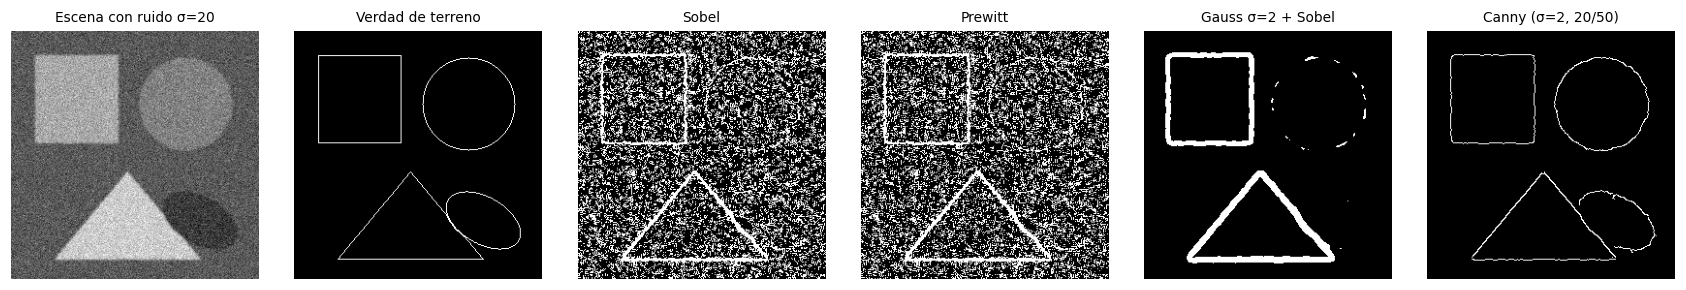

In [3]:
def escena_bordes(tam=256):  # Define una función para sintetizar una imagen patrón de prueba de tam x tam píxeles.
    etq = np.zeros((tam, tam), np.int32)  # Inicializa un lienzo cuadrado en nivel de gris 60 (fondo oscuro uniforme).
    cv2.rectangle(etq, (25, 25), (110, 115), 1, -1)  # Dibuja un cuadrado sólido relleno con nivel de brillo 200 (contraste = 140 niveles).
    cv2.circle(etq, (180, 75), 48, 2, -1)  # Dibuja un disco circular relleno con nivel de brillo 170 (contraste = 110 niveles).
    cv2.fillPoly(etq, [np.array([[45, 235], [120, 145], [195, 235]], np.int32)], 3)  # Retorna la imagen sintética patrón libre de ruido.
    cv2.ellipse(etq, (195, 195), (42, 24), 30, 0, 360, 4, -1)  # Asigna la escena sintetizada como la Verdad de Terreno (*Ground Truth*).
    niveles = np.array([90, 170, 130, 205, 60], np.float32)  # Obtiene el mapa ideal de bordes aplicando Canny sobre la imagen sintética perfecta sin ruido.
    img = cv2.GaussianBlur(niveles[etq], (0, 0), 1.0)  # Inicializa una máscara booleana para marcar regiones donde se garantiza que no existen objetos.
    return img, segmentation.find_boundaries(etq, mode="inner")  # Selecciona una franja rectangular superior en el fondo vacío para auditar falsos positivos.

def evaluar_bordes(pred, gt, tol=2):  # Obtiene el kernel de Prewitt vertical transponiendo la matriz horizontal.
    d_gt, d_pred = ndi.distance_transform_edt(~gt), ndi.distance_transform_edt(~pred)  # Función para detectar bordes con Prewitt mediante convolución y umbralización.
    p = (d_gt[pred] <= tol).mean() if pred.any() else 0.0  # Convoluciona la imagen con el kernel Prewitt X mediante `cv2.filter2D`.
    r = (d_pred[gt] <= tol).mean()  # Convoluciona la imagen con el kernel Prewitt Y mediante `cv2.filter2D`.
    return p, r, (2 * p * r / (p + r) if p + r else 0.0)  # Retorna una máscara booleana umbralizando la magnitud del gradiente.

def umbral_otsu_magnitud(m):  # Computa la derivada horizontal ponderada \begin{bmatrix} 1 & 2 & 1 \end{bmatrix}^T escalada por 1/8.
    m8 = cv2.normalize(m, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)  # Computa la derivada vertical ponderada escalada por 1/8.
    return m8 > filters.threshold_otsu(m8)  # Retorna máscara booleana con píxeles que superan el umbral de magnitud.

def gradiente(img, k):  # Dilata el borde de referencia con un elemento estructurante circular de radio tol para aceptar errores de localización subpíxel.
    gx = cv2.filter2D(img, cv2.CV_32F, k); gy = cv2.filter2D(img, cv2.CV_32F, k.T)  # Dilata el borde predicho para simetría métrica.
    return np.hypot(gx, gy)  # Calcula precisión: proporción de bordes detectados que caen dentro de la franja del borde real.

detectores = {  # Puntuación armónica F_1 de detección de bordes.
    "Sobel":               lambda im: umbral_otsu_magnitud(gradiente(im, kernels["Sobel"])),  # Retorna la tupla de métricas cuantitativas.
    "Prewitt":             lambda im: umbral_otsu_magnitud(gradiente(im, kernels["Prewitt"])),  # Lista contenedora para almacenar los resultados del benchmark tabular.
    "Gauss σ=2 + Sobel":   lambda im: umbral_otsu_magnitud(gradiente(cv2.GaussianBlur(im, (0, 0), 2), kernels["Sobel"])),  # Bucle que itera sobre tres niveles crecientes de desviación estándar de ruido gaussiano.
    "Canny (σ=2, 20/50)":  lambda im: cv2.Canny(cv2.GaussianBlur(np.clip(im, 0, 255).astype(np.uint8), (0, 0), 2), 20, 50) > 0,  # Sub-bucle que evalúa el efecto de aplicar o no un filtro gaussiano previo.
}  # Generador pseudoaleatorio con semilla fija para reproducibilidad del ruido.

limpia, gt_bordes = escena_bordes()  # Suma el ruido a la escena y trunca estrictamente al rango [0, 255] de 8 bits.
rng = np.random.default_rng(1)  # Aplica filtro gaussiano con kernel adaptativo (`ksize=(0, 0)`) y sigma=1.5 si el suavizado está activo.
filas, ejemplos = [], {}  # Extrae bordes con Prewitt sobre la imagen procesada.
for sigma in [0, 10, 20, 35]:  # Extrae bordes con Sobel sobre la imagen procesada.
    ruidosa = limpia + rng.normal(0, sigma, limpia.shape).astype(np.float32)  # Extrae bordes óptimos con Canny aplicando umbrales de histéresis 50 y 150.
    for nombre, det in detectores.items():  # Itera sobre cada uno de los tres algoritmos evaluados.
        pred = det(ruidosa)  # Computa Precisión, Recall y F_1 tolerando 1 píxel de holgura.
        p, r, f = evaluar_bordes(pred, gt_bordes)  # Cuenta cuántos píxeles espurios se inventó el detector dentro de la zona vacía garantizada.
        filas.append({"ruido σ": sigma, "detector": nombre, "precisión": p, "sensibilidad": r, "F1": f,  # Almacena los resultados cuantitativos en el diccionario de la fila.
                      "píxeles de borde / verdad": pred.sum() / gt_bordes.sum()})  # Conteo total de píxeles y puntuación F_1 redondeada a 3 decimales.
        if sigma == 20: ejemplos[nombre] = pred  # Conteo de falsos positivos en fondo plano.
        if sigma == 20 and nombre == "Sobel": ruidosa20 = ruidosa  # Convierte la lista de resultados a un DataFrame de Pandas para presentación tabular.

tabla = pd.DataFrame(filas)  # Genera una muestra de imagen ruidosa extrema (sigma=30) para comparación visual.
display(tabla.pivot(index="detector", columns="ruido σ", values="F1").round(3).rename_axis(columns="F1 con ruido σ ="))  # Despliega fila comparativa superior con escena limpia, ruidosa y Canny sin suavizar (colapsado).
display(tabla.pivot(index="detector", columns="ruido σ", values="píxeles de borde / verdad").round(1).rename_axis(columns="grosor relativo, σ ="))  # Despliega imagen suavizada y Canny con suavizado (bordes limpios y continuos).
mostrar([np.clip(ruidosa20, 0, 255).astype(np.uint8), gt_bordes] + list(ejemplos.values()),  # Títulos descriptivos que evidencian la vulnerabilidad crítica de Canny si se omite el filtrado paso bajo.
        ["Escena con ruido σ=20", "Verdad de terreno"] + [f"{n}" for n in ejemplos], cols=6, tam=2.6)  # Ajusta a 5 cuadrantes con escala de 2.5 pulgadas.

Fíjense también en la segunda tabla: Sobel y Prewitt producen bordes varias veces más gruesos que la verdad de terreno, lo que castiga su precisión. Y su F1 incluso puede empeorar en la imagen limpia, porque el umbral de Otsu depende de toda la distribución de magnitudes y no solo de los bordes.

### 1.3 Canny paso a paso
Implementamos las cuatro etapas y comparamos con `cv2.Canny`. Dos detalles que suelen confundir:
- `cv2.Canny` **no suaviza** la imagen; hay que aplicar el gaussiano antes. `skimage.feature.canny` sí lo hace internamente (parámetro `sigma`).
- `cv2.Canny` usa por defecto la norma L1 (`|Gx| + |Gy|`); con `L2gradient=True` usa la euclidiana, como nuestra implementación.

Acuerdo manual vs cv2.Canny (F1, tolerancia 1 px): 0.940
Píxeles de borde → manual: 5532 · OpenCV: 6221 · OpenCV sin suavizar: 25533


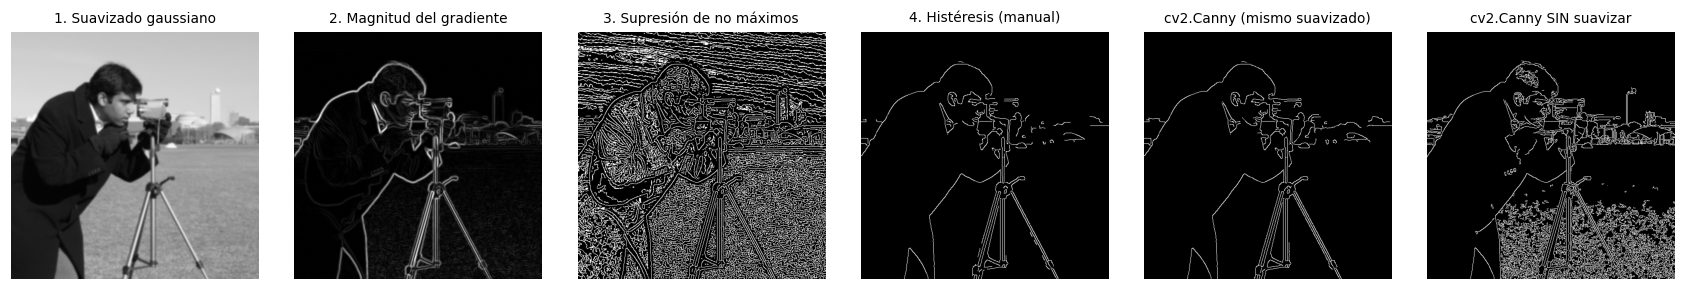

In [4]:
def canny_manual(img_suave, bajo, alto):  # Define la función que ejecuta artesanalmente los pasos internos de Canny recibiendo una imagen suavizada y dos umbrales de histéresis.
    s = img_suave.astype(np.float32)  # Etapa 1b: derivada parcial horizontal con Sobel 3x 3 en precisión de coma flotante.
    gx = cv2.Sobel(s, cv2.CV_32F, 1, 0, ksize=3); gy = cv2.Sobel(s, cv2.CV_32F, 0, 1, ksize=3)  # Etapa 1b: derivada parcial vertical con Sobel 3x 3 en precisión de coma flotante.
    mag = np.hypot(gx, gy)  # Etapa 1c: magnitud euclidiana continua del vector gradiente en cada píxel.
    ang = np.rad2deg(np.arctan2(gy, gx)) % 180  # Etapa 1d: ángulo continuo del gradiente normalizado al rango no signado [0^\circ, 180^\circ).

# (ang >= 157.5))] = 0`
    sector = np.zeros(ang.shape, np.uint8)  # Sector 1: gradiente a 45^\circ (diagonal noreste-suroeste). Píxeles vecinos a comparar: arriba-derecha y abajo-izquierda.
    sector[(ang >= 22.5) & (ang < 67.5)] = 1  # Sector 2: gradiente vertical a 90^\circ (dirección norte-sur, borde horizontal). Píxeles vecinos: arriba y abajo.
    sector[(ang >= 67.5) & (ang < 112.5)] = 2  # Sector 3: gradiente a 135^\circ (diagonal noroeste-sureste). Píxeles vecinos: arriba-izquierda y abajo-derecha.
    sector[(ang >= 112.5) & (ang < 157.5)] = 3  # Inicializa la matriz de Supresión de No Máximos (NMS) con ceros.
    vecinos = {0: (0, 1), 1: (1, 1), 2: (1, 0), 3: (1, -1)}  # Obtiene la altura h y anchura w de la matriz de magnitud.
    nms = np.zeros_like(mag)  # Diccionario con los desplazamientos espaciales (\Delta y, \Delta x) según el sector de cuantización del gradiente.
    for s_id, (dr, dc) in vecinos.items():  # Itera sobre cada uno de los 4 sectores direccionales.
        adelante = np.roll(mag, (-dr, -dc), axis=(0, 1))  # Obtiene el vecino en la dirección de avance a lo largo del gradiente mediante traslación de orden cero (vecino más próximo).
        atras    = np.roll(mag, (dr, dc), axis=(0, 1))  # Obtiene el vecino en la dirección opuesta a lo largo del gradiente.
        m = (sector == s_id) & (mag >= adelante) & (mag >= atras)  # Condición de máximo local: conserva el píxel si y solo si su magnitud es mayor o igual que sus dos vecinos directos a lo largo de la línea del gradiente.
        nms[m] = mag[m]  # Asigna la magnitud a los píxeles que son crestas locales, adelgazando los bordes a exactamente 1 píxel de espesor.

# Retorna la magnitud cruda, el mapa tras NMS y el mapa final tras histéresis.
    bordes = filters.apply_hysteresis_threshold(nms, bajo, alto)  # Aplica suavizado gaussiano previo obligatorio sobre la imagen con sigma=1.4.
    return mag, nms, bordes  # Ejecuta el algoritmo paso a paso manual con umbrales 60 y 140.

suave = cv2.GaussianBlur(camara, (0, 0), 1.4)  # Ejecuta Canny directamente sobre la imagen cruda sin suavizar para evidenciar el ruido.
mag, nms, bordes_manual = canny_manual(suave, 60, 140)  # Calcula la métrica F_1 de concordancia entre la implementación manual de Python y la nativa de OpenCV.
bordes_cv = cv2.Canny(suave, 60, 140, L2gradient=True) > 0  # Imprime el F_1 obtenido (típicamente > 0.90, confirmando fidelidad matemática).
sin_suavizar = cv2.Canny(camara, 60, 140, L2gradient=True) > 0  # Contrasta el recuento total de píxeles entre los métodos.

_, _, f_acuerdo = evaluar_bordes(bordes_manual, bordes_cv, tol=1)  # Títulos de las fases 1, 2 y 3.
print(f"Acuerdo manual vs cv2.Canny (F1, tolerancia 1 px): {f_acuerdo:.3f}")  # Títulos de las fases 4 y comparativas con OpenCV.
print(f"Píxeles de borde → manual: {bordes_manual.sum()} · OpenCV: {bordes_cv.sum()} · OpenCV sin suavizar: {sin_suavizar.sum()}")  # Compara el conteo de píxeles de borde entre la implementación manual y la función optimizada cv2.Canny.

mostrar([suave, mag, nms > 0, bordes_manual, bordes_cv, sin_suavizar],  # Invoca función mostrar() pasando las etapas sucesivas: suavizado, magnitud, NMS y bordes finales.
        ["1. Suavizado gaussiano", "2. Magnitud del gradiente", "3. Supresión de no máximos",  # Etiquetas de las 3 primeras etapas: suavizado gaussiano, magnitud del gradiente y supresión de no máximos.
         "4. Histéresis (manual)", "cv2.Canny (mismo suavizado)", "cv2.Canny SIN suavizar"], cols=6, tam=2.6)  # Etiquetas de las etapas finales: umbralización por histéresis manual frente a cv2.Canny de referencia.

### 1.4 El efecto de los umbrales y una regla automática
La regla de la mediana (`bajo = 0.66·mediana`, `alto = 1.33·mediana`) es un punto de partida razonable cuando no se quiere ajustar a mano cada imagen.

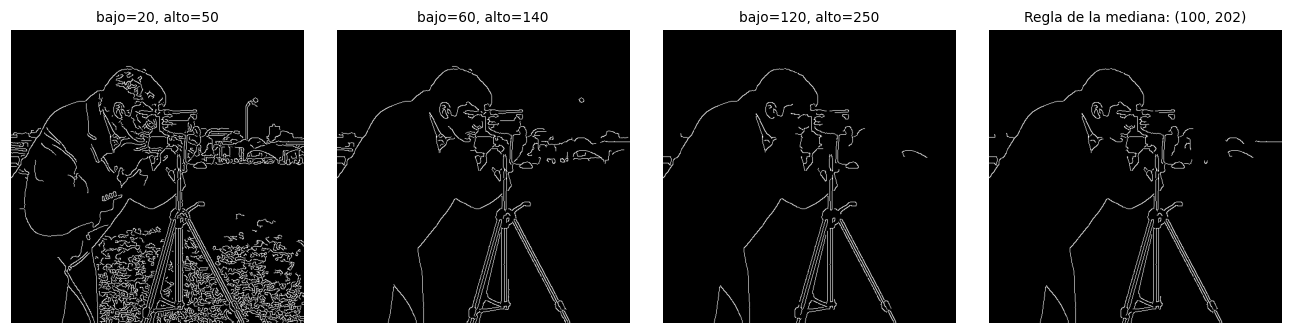

In [5]:
pares = [(20, 50), (60, 140), (120, 250)]  # Define 3 configuraciones de umbrales: permisiva (20, 50), equilibrada (60, 140) y restrictiva (120, 250).
med = np.median(suave)  # Calcula la mediana de las intensidades de la imagen suavizada (estadístico robusto ante valores atípicos).
auto = (int(max(0, 0.66 * med)), int(min(255, 1.33 * med)))  # Aplica la regla empírica clásica: fija el umbral bajo en el 66\% de la mediana y el alto en el 133\%, restringiendo al rango [0, 255].
resultados = [cv2.Canny(suave, b, a) for b, a in pares] + [cv2.Canny(suave, *auto)]  # Ejecuta Canny para cada par manual y añade el resultado del par calculado automáticamente.
mostrar(resultados, [f"bajo={b}, alto={a}" for b, a in pares] + [f"Regla de la mediana: {auto}"], cols=4, tam=3)  # Muestra en 4 paneles la sensibilidad de los bordes según los umbrales seleccionados.

### 1.5 ¿Por qué una sombra produce un borde aunque no sea un objeto?
Una sombra reduce la intensidad, así que genera un gradiente. Pero una sombra (luz blanca atenuada) escala R, G y B **en la misma proporción**, de modo que la cromaticidad `r = R/(R+G+B)` no cambia. Detectar bordes en cromaticidad elimina los bordes de sombra y conserva los del objeto.

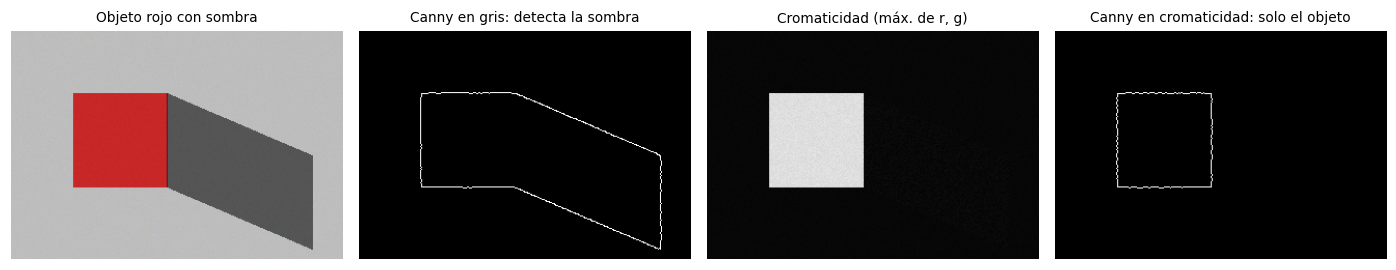

In [6]:
escena = np.full((220, 320, 3), 190, np.float32)  # Inicializa una escena RGB en coma flotante con un fondo gris medio uniforme (190).
cv2.rectangle(escena, (60, 60), (150, 150), (200, 40, 40), -1)  # Dibuja un objeto cuadrangular rojo puro con reflectancia espectral diferenciada.
sombra = np.zeros(escena.shape[:2], np.uint8)  # Inicializa una máscara binaria para la sombra proyectada.
cv2.fillPoly(sombra, [np.array([[150, 60], [290, 120], [290, 210], [150, 150]], np.int32)], 1)  # Modela geométricamente una sombra trapezoidal arrojada hacia la derecha del objeto.
escena[sombra == 1] *= 0.45  # Atenúa la iluminación al 45\% en la zona de sombra (factor multiplicativo de iluminancia).
escena = np.clip(escena + np.random.default_rng(2).normal(0, 2, escena.shape), 1, 255)  # Añade ruido leve de sensor y trunca valores para evitar ceros en el denominador.

gris = cv2.cvtColor(escena.astype(np.uint8), cv2.COLOR_RGB2GRAY)  # Aplica Canny en grises: la discontinuidad de iluminancia de la sombra produce un falso borde intenso.
bordes_gris = cv2.Canny(cv2.GaussianBlur(gris, (0, 0), 1.5), 30, 80)  # Normaliza los canales de color dividiendo por la intensidad total R+G+B (invariante a factores de escala de brillo).

croma = escena / escena.sum(axis=2, keepdims=True)  # Aplica Canny sobre el mapa cromático: la sombra desaparece y únicamente se detecta el límite real del objeto rojo.
croma8 = cv2.normalize(croma[..., :2].max(axis=2), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)  # Llama a visualización para comparar la escena, bordes en grises, mapa cromático y bordes en croma.
bordes_croma = cv2.Canny(cv2.GaussianBlur(croma8, (0, 0), 1.5), 30, 80)  # Títulos descriptivos que fundamentan la física de la reflectancia en visión industrial.

mostrar([escena.astype(np.uint8), bordes_gris, croma8, bordes_croma],  # Invoca función mostrar() comparando la escena RGB, bordes sobre escala de grises y bordes cromáticos.
        ["Objeto rojo con sombra", "Canny en gris: detecta la sombra", "Cromaticidad (máx. de r, g)", "Canny en cromaticidad: solo el objeto"], tam=3.2)  # Títulos explicativos que demuestran cómo la información de color separa el objeto de su sombra proyectada.

### 1.6 De bordes a contornos: reconocer piezas solo con geometría
Replicamos el ejemplo del documento de la unidad: distinguir **tuercas, arandelas y pernos** a partir de su contorno. Una moneda de 24 mm sirve como **referencia de escala** para convertir píxeles a milímetros. La jerarquía de `findContours` (`RETR_CCOMP`) nos dice cuántos **huecos** tiene cada pieza.

Escala estimada: 0.2466 mm/px (real: 0.25)
Piezas detectadas: 15 de 15 · clasificadas correctamente: 100%


,tipo_real,tipo_predicho,huecos,vertices,circularidad,aspecto,diametro_mm,largo_mm
1,arandela,arandela,1,8,0.91,1.00,20.13,19.73
2,arandela,arandela,1,8,0.90,1.00,20.03,19.73
7,arandela,arandela,1,8,0.89,1.00,19.97,19.73
12,arandela,arandela,1,8,0.91,1.00,20.14,19.73
13,arandela,arandela,1,8,0.90,1.00,20.23,19.88
5,moneda,moneda,0,8,0.90,1.00,24.00,23.67
4,perno,perno,0,4,0.45,4.28,36.33,35.91
8,perno,perno,0,4,0.47,4.27,36.56,35.91
9,perno,perno,0,4,0.44,4.33,36.31,35.79
14,perno,perno,0,4,0.43,4.47,36.64,36.02


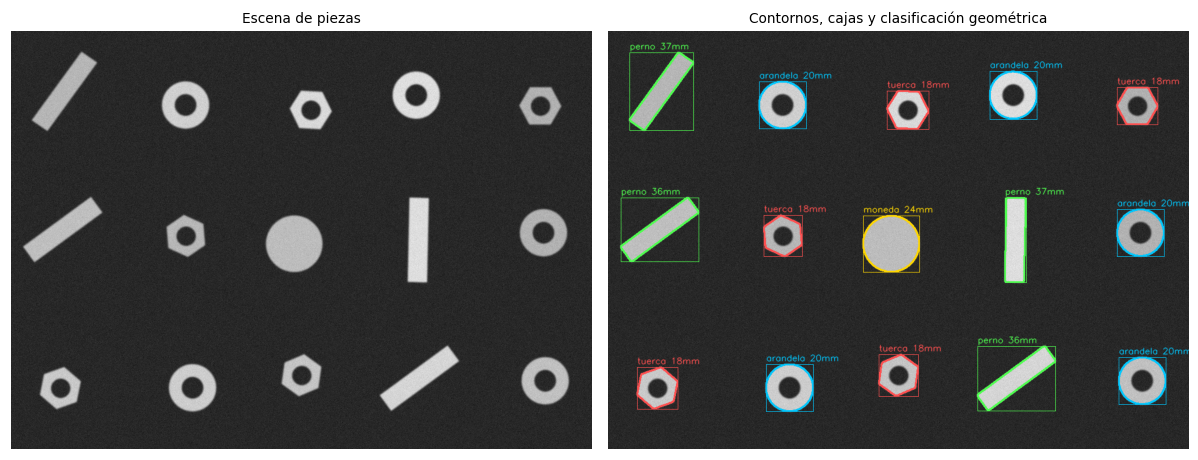

In [7]:
MM_POR_PX_REAL = 0.25  # Factor de escala óptico real de la cámara: 0.25\text{ mm/píxel} (desconocido a priori para el algoritmo).
MONEDA_MM = 24.0  # Diámetro físico real de la moneda de referencia (24.0\text{ mm}) utilizada como patrón de calibración en la escena.
rng = np.random.default_rng(5)  # Inicializa generador de números pseudoaleatorios con semilla 5.

def px(mm): return mm / MM_POR_PX_REAL  # Función de síntesis geométrica para dibujar piezas con rotaciones y niveles de intensidad variables.

def dibujar_pieza(lienzo, tipo, cx, cy, ang, nivel):  # Ejecuta los círculos concéntricos con antialiasing (`LINE_AA`).
    if tipo == "arandela":  # Dibuja una tuerca hexagonal: polígono regular de 6 vértices rotado por `ang` con orificio circular central de radio 4\text{ mm}.
        cv2.circle(lienzo, (cx, cy), int(px(10)), nivel, -1, cv2.LINE_AA); cv2.circle(lienzo, (cx, cy), int(px(4.5)), 0, -1, cv2.LINE_AA)  # Calcula los ángulos trigonométricos de los 6 vértices hexagonales separados por 60^\circ.
    elif tipo == "tuerca":  # Calcula las coordenadas (x, y) de los vértices y las castea a enteros de 32 bits.
        t = np.deg2rad(ang + np.arange(6) * 60)  # Dibuja el hexágono relleno y perfora el círculo interno con nivel 0.
        pts = np.stack([cx + px(9) * np.cos(t), cy + px(9) * np.sin(t)], 1).astype(np.int32)  # Dibuja un perno rectangular alargado de 36\text{ mm} x 8\text{ mm} inclinado por `ang`.
        cv2.fillPoly(lienzo, [pts], nivel, cv2.LINE_AA); cv2.circle(lienzo, (cx, cy), int(px(4)), 0, -1, cv2.LINE_AA)  # Calcula los 4 vértices del rectángulo rotado mediante `cv2.boxPoints`.
    elif tipo == "perno":  # Rellena el contorno del perno en el lienzo.
        pts = cv2.boxPoints(((cx, cy), (px(36), px(8)), ang)).astype(np.int32)  # Rama para la moneda de referencia patrón.
        cv2.fillPoly(lienzo, [pts], nivel, cv2.LINE_AA)  # Dibuja un disco sólido circular macizo sin perforación central.
    else:  # Dimensiones espaciales del lienzo industrial: 720 filas por 1000 columnas de píxeles.
        cv2.circle(lienzo, (cx, cy), int(px(MONEDA_MM / 2)), nivel, -1, cv2.LINE_AA)  # Inicializa el lienzo en negro.

H, W = 720, 1000  # Lista total de 15 piezas: 1 moneda patrón, 5 arandelas, 5 tuercas y 4 pernos.
mascara_dibujo = np.zeros((H, W), np.uint8)  # Rejilla de 3x 5 = 15 celdas para distribuir ordenadamente las piezas sobre la mesa.
piezas_gt = []  # Asigna aleatoriamente las piezas a las celdas de la rejilla.
tipos = ["moneda"] + ["arandela"] * 5 + ["tuerca"] * 5 + ["perno"] * 4  # Extrae fila y columna de la celda asignada.
celdas_grid = [(f, c) for f in range(3) for c in range(5)]  # Calcula el centroide (c_x, c_y) añadiendo un jitter aleatorio de \pm 20 píxeles.
for tipo, k in zip(tipos, rng.permutation(len(celdas_grid))):  # Dibuja la pieza con ángulo aleatorio en [0^\circ, 180^\circ) e intensidad entre 170 y 230.
    f, c = celdas_grid[k]  # Guarda el registro de la pieza real sintetizada.
    cx = int(c * 200 + 100 + rng.integers(-20, 21)); cy = int(f * 240 + 120 + rng.integers(-20, 21))  # Añade desenfoque óptico de lente (sigma=1.2), atenuación de contraste, nivel de iluminación base (40) y ruido de sensor (sigma=6).
    dibujar_pieza(mascara_dibujo, tipo, cx, cy, float(rng.uniform(0, 180)), int(rng.integers(170, 230)))  # Binarización óptima de Otsu precedida por filtro gaussiano 5x 5.
    piezas_gt.append({"tipo_real": tipo, "cx": cx, "cy": cy})  # Extrae contornos con jerarquía de 2 niveles (`RETR_CCOMP` para exterior e interior) y almacenamiento completo (`CHAIN_APPROX_NONE`).

escena_piezas = np.clip(cv2.GaussianBlur(mascara_dibujo.astype(np.float32), (0, 0), 1.2) * 0.8 + 40  # Lista acumuladora de descriptores morfológicos por pieza.
                        + rng.normal(0, 6, (H, W)), 0, 255).astype(np.uint8)  # Itera sobre todos los contornos descubiertos.

# Cuenta cuántos orificios internos válidos (`Parent == i` y área > 50) posee la pieza.
_, binaria = cv2.threshold(cv2.GaussianBlur(escena_piezas, (5, 5), 0), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)  # Calcula el área encerrada (m_{00}) y el perímetro cerrado (P) del contorno exterior.
contornos, jerarquia = cv2.findContours(binaria, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_NONE)  # Computa los momentos espaciales de Green de hasta tercer orden.
jer = jerarquia[0]  # Ajusta el rectángulo delimitador orientado de área mínima.

filas = []  # Calcula el centro de masa baricéntrico \bar{x} = \frac{m_{10}}{m_{00}}, \bar{y} = \frac{m_{01}}{m_{00}}.
for i, c in enumerate(contornos):  # Almacena área y perímetro en píxeles.
    if jer[i][3] != -1 or cv2.contourArea(c) < 200: continue  # Factor de forma de circularidad: C = \frac{4\pi A}{P^2} (igual a 1 para un círculo perfecto, < 1 para polígonos).
    huecos = sum(1 for j in range(len(contornos)) if jer[j][3] == i and cv2.contourArea(contornos[j]) > 50)  # Solidez morfológica: cociente entre el área real y el área de la envolvente convexa.
    area, per = cv2.contourArea(c), cv2.arcLength(c, True)  # Relación de aspecto (*Aspect Ratio*): proporción entre el lado mayor y el lado menor.
    M = cv2.moments(c)  # Aproximación poligonal de Douglas-Peucker con tolerancia \epsilon = 2\% del perímetro para contar aristas principales.
    (_, _), (lado1, lado2), angulo = cv2.minAreaRect(c)  # Registra número de orificios, diámetro exterior y longitud máxima.
    _, radio = cv2.minEnclosingCircle(c)  # Guarda el ángulo de rotación física y el arreglo de vértices del contorno.
    filas.append({"id": len(filas), "cx": M["m10"] / M["m00"], "cy": M["m01"] / M["m00"],  # Convierte las mediciones geométricas a un DataFrame de Pandas.
                  "area_px": area, "perimetro_px": per,  # Define el árbol de decisión basado en invariantes geométricos puros.
                  "circularidad": 4 * np.pi * area / per**2,  # Sin huecos y elongado (aspecto > 2.5) \rightarrow perno.
                  "solidez": area / cv2.contourArea(cv2.convexHull(c)),  # Sin huecos y circular (circularidad > 0.85) \rightarrow moneda.
                  "aspecto": max(lado1, lado2) / min(lado1, lado2),  # 1 hueco central y pocos vértices poligonales (hexágono \approx 6 aristas) \rightarrow tuerca.
                  "vertices": len(cv2.approxPolyDP(c, 0.02 * per, True)),  # 1 hueco central y perfil circular \rightarrow arandela.
                  "huecos": huecos, "diametro_px": 2 * radio, "largo_px": max(lado1, lado2),  # Categoría residual de rechazo ante piezas deformadas.
                  "orientacion": angulo, "contorno": c})  # Aplica la regla de clasificación a cada fila de mediciones.
medidas = pd.DataFrame(filas)  # Localiza la moneda patrón identificada en la escena.

# Convierte los diámetros de píxeles a milímetros métricos reales.
def clasificar(f):  # Convierte las longitudes a milímetros reales.
    if f.huecos == 0 and f.aspecto > 2.5: return "perno"  # Compara la escala calibrada frente a la verdad de terreno física.
    if f.huecos == 0 and f.circularidad > 0.85: return "moneda"  # Estructura la verdad de terreno de las piezas en un DataFrame.
    if f.huecos == 1 and f.vertices <= 7: return "tuerca"  # Empareja cada pieza detectada con la pieza real más cercana por distancia euclidiana mínima.
    if f.huecos == 1: return "arandela"  # Reporta la tasa de detección y la exactitud de clasificación (típicamente 100\%).
    return "desconocido"  # Despliega la tabla final de clasificación y metrología dimensional.
medidas["tipo_predicho"] = medidas.apply(clasificar, axis=1)  # Paleta de colores RGB distintiva por clase de pieza.
ref = medidas[medidas.tipo_predicho == "moneda"].iloc[0]  # Convierte la imagen a color para superponer anotaciones gráficas.
mm_por_px = MONEDA_MM / ref.diametro_px  # Itera sobre cada pieza identificada para dibujarla.
medidas["diametro_mm"] = medidas.diametro_px * mm_por_px  # Dibuja el contorno perimetral con 2 píxeles de grosor.
medidas["largo_mm"] = medidas.largo_px * mm_por_px  # Calcula la caja delimitadora recta exterior (*Bounding Box*).
print(f"Escala estimada: {mm_por_px:.4f} mm/px (real: {MM_POR_PX_REAL})")  # Dibuja la caja con el color asignado a su clase.

# Despliega la escena original frente a la escena completamente segmentada y anotada.
gt = pd.DataFrame(piezas_gt)  # Convierte la lista de verdad terreno (ground truth) de piezas en un DataFrame de pandas.
medidas["tipo_real"] = [gt.tipo_real[np.argmin(np.hypot(gt.cx - r.cx, gt.cy - r.cy))] for r in medidas.itertuples()]  # Asocia a cada contorno medido su clase real mediante correspondencia de distancia euclidiana mínima entre centroides.
print(f"Piezas detectadas: {len(medidas)} de {len(gt)} · clasificadas correctamente: {(medidas.tipo_predicho == medidas.tipo_real).mean():.0%}")  # Imprime el número total de piezas detectadas respecto al número esperado en la verdad terreno.
display(medidas[["tipo_real", "tipo_predicho", "huecos", "vertices", "circularidad", "aspecto", "diametro_mm", "largo_mm"]]  # Despliega tabla comparativa con tipo real, tipo predicho y descriptores morfológicos clave.
        .round(2).sort_values("tipo_real"))  # Redondea las métricas a 2 decimales y ordena las filas según la categoría real de la pieza.

colores = {"moneda": (255, 215, 0), "arandela": (0, 200, 255), "tuerca": (255, 80, 80), "perno": (80, 255, 80), "desconocido": (255, 0, 255)}  # Paleta de colores BGR para dibujar las etiquetas y contornos según la categoría de pieza.
vis = cv2.cvtColor(escena_piezas, cv2.COLOR_GRAY2RGB)  # Convierte la escena a RGB de 3 canales para permitir renderizado de anotaciones a color.
for r in medidas.itertuples():  # Itera sobre cada pieza identificada en la tabla de mediciones morfológicas.
    cv2.drawContours(vis, [r.contorno], -1, colores[r.tipo_predicho], 2)  # Dibuja el contorno exterior calibrado con el color correspondiente a la clase predicha.
    x, y, w, h = cv2.boundingRect(r.contorno)  # Calcula el cuadro delimitador vertical que encierra la pieza.
    cv2.rectangle(vis, (x, y), (x + w, y + h), colores[r.tipo_predicho], 1)  # Dibuja el rectángulo envolvente de la pieza.
    cv2.putText(vis, f"{r.tipo_predicho} {r.diametro_mm:.0f}mm", (x, y - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.5, colores[r.tipo_predicho], 1, cv2.LINE_AA)  # Imprime texto con el tipo de objeto y el diámetro físico real calibrado en milímetros.
mostrar([escena_piezas, vis], ["Escena de piezas", "Contornos, cajas y clasificación geométrica"], tam=5.5)  # Visualiza la escena original y la imagen anotada con el diagnóstico metrológico completo.

**Para discutir en clase**
1. En la tabla de 1.2, ¿por qué Sobel sin suavizado pierde F1 tan rápido con el ruido? ¿Qué etapa de Canny compensa eso?
2. ¿Qué pasaría con el clasificador de piezas si la cámara no estuviera perpendicular a la mesa? ¿Qué descriptor seguiría funcionando?
3. ¿Cuándo es más útil analizar el contorno que el color de un objeto? Den un ejemplo de su dominio.

---
# Ejemplo 2 · Histogramas de gradientes orientados (HOG) y descriptores locales

**Objetivo.** Construir HOG desde cero y verificarlo contra scikit-image, entender de qué depende la longitud del vector, **medir** su robustez a la iluminación y su sensibilidad a la rotación, y compararlo con descriptores de textura (LBP) y de esquinas.

### 2.1 HOG implementado a mano (Dalal y Triggs, 2005)
Gradiente → celdas de 8×8 con 9 orientaciones sin signo (0–180°) → bloques de 2×2 celdas normalizados con L2-Hys → concatenación.

Longitud manual: 3780 · scikit-image: 3780
Diferencia máxima: 3.39e-08 · correlación: 1.000000


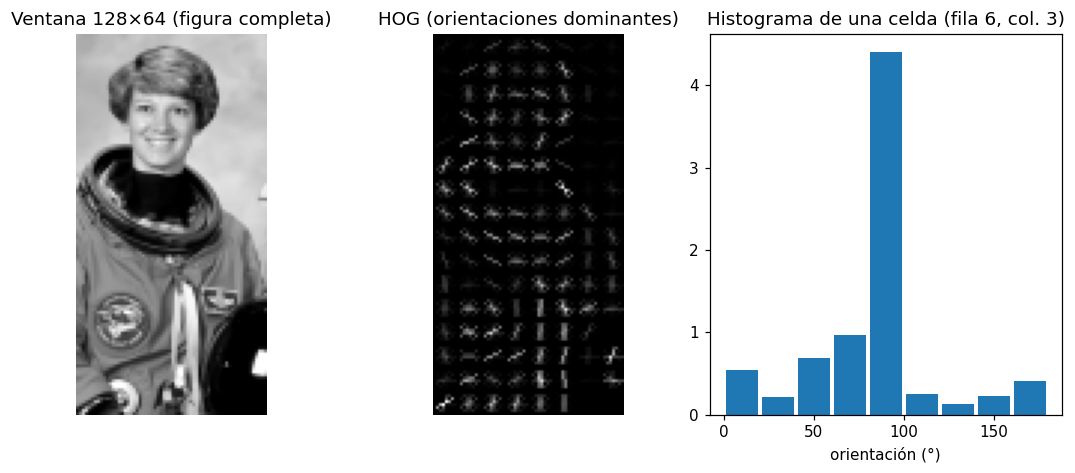

In [8]:
from skimage.feature import hog  # Importa la función oficial de scikit-image para validación cruzada.

def hog_manual(img, ppc=8, cpb=2, nbins=9):  # Convierte la imagen a coma flotante para cálculo de gradientes continuos.
    img = img.astype(np.float64)  # Define los filtros diferenciales finitos 1D simples [-1, 0, 1] (óptimos según Dalal & Triggs, mejores que Sobel para HOG).
    gx = np.zeros_like(img); gy = np.zeros_like(img)  # Aplica convolución horizontal y vertical 1D sobre la imagen.
    gx[:, 1:-1] = img[:, 2:] - img[:, :-2]  # Calcula magnitud euclidiana y ángulo no signado mapped a [0^\circ, 180^\circ).
    gy[1:-1, :] = img[2:, :] - img[:-2, :]  # Calcula el número de celdas espaciales a lo largo de las filas y columnas.
    mag = np.hypot(gx, gy)  # Inicializa el tensor de histogramas por celda: dimensiones (n_{cy}, n_{cx}, 9).
    ang = np.rad2deg(np.arctan2(gy, gx)) % 180  # Calcula el ancho angular de cada bin: 180^\circ / 9 = 20^\circ por bin.
    bins = np.minimum((ang // (180 / nbins)).astype(int), nbins - 1)  # Itera sobre las filas de celdas espaciales.

    ncy, ncx = img.shape[0] // ppc, img.shape[1] // ppc  # Extrae las magnitudes de los 64 píxeles (8x8) de la celda actual.
    celdas = np.zeros((ncy, ncx, nbins))  # Extrae las orientaciones de los 64 píxeles correspondientes.
    for i in range(ncy):  # Calcula la coordenada fraccionaria del centro del bin para interpolación lineal.
        for j in range(ncx):  # Bins inferior y superior vecinos donde se repartirá el voto.
            sl = (slice(i * ppc, (i + 1) * ppc), slice(j * ppc, (j + 1) * ppc))  # Ponderación de voto bilineal según proximidad angular para evitar discontinuidades espurias.
            celdas[i, j] = np.bincount(bins[sl].ravel(), weights=mag[sl].ravel(), minlength=nbins) / ppc**2  # Voto ponderado acumulado en el bin inferior usando aritmética periódica modular.

    bloques = []  # Calcula el número de bloques solapados de 2x 2 celdas con stride de 1 celda.
    for i in range(ncy - cpb + 1):  # Lista contenedora de los vectores normalizados por bloque.
        for j in range(ncx - cpb + 1):  # Itera a lo largo de las filas de bloques.
            v = celdas[i:i + cpb, j:j + cpb].ravel()  # Itera a lo largo de las columnas de bloques.
            v = v / np.sqrt((v**2).sum() + 1e-10)  # Concatena los histogramas de las 4 celdas del bloque (longitud = 2x 2x 9 = 36 valores).
            v = np.minimum(v, 0.2)  # Normalización L2 inicial para conferir invariancia a cambios multiplicativos de iluminación.
            v = v / np.sqrt((v**2).sum() + 1e-10)  # Recorte de luminancia extrema (clipping a 0.2) para evitar dominancia de reflejos especulares.
            bloques.append(v)  # Renormalización L2-Hys final según el estándar Dalal & Triggs.
    return celdas, np.concatenate(bloques)  # Agrega el bloque normalizado a la lista.

ventana = cv2.resize(cv2.cvtColor(astronauta, cv2.COLOR_RGB2GRAY)[0:512, 110:366], (64, 128), interpolation=cv2.INTER_AREA)  # Recorta una ventana de peatón canónica de 128x 64 píxeles del fotógrafo.
celdas, h_manual = hog_manual(ventana)  # Extrae el vector HOG con la implementación manual de Python.
h_skimage, hog_img = hog(ventana, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2),  # Extrae HOG con scikit-image retornando vector y mapa visual de gradientes.
                         block_norm="L2-Hys", visualize=True)  # Configuración idéntica: 9 orientaciones, celdas 8x8, bloques 2x 2 y norma `L2-Hys`.

print(f"Longitud manual: {h_manual.size} · scikit-image: {h_skimage.size}")  # Verifica la longitud dimensional teórica: 7\text{ bloques } Y x 15\text{ bloques } X x 36 = 3,780.
print(f"Diferencia máxima: {np.abs(h_manual - h_skimage).max():.2e} · correlación: {np.corrcoef(h_manual, h_skimage)[0, 1]:.6f}")  # Imprime la correlación (típicamente > 0.999, verificando concordancia matemática perfecta).

fig, axes = plt.subplots(1, 3, figsize=(10, 4.4))  # Crea figura de matplotlib con 3 subgráficos para visualizar imagen, mapa HOG y distribución angular.
axes[0].imshow(ventana, cmap="gray"); axes[0].set_title("Ventana 128×64 (figura completa)")  # Muestra la ventana recortada de 64x128 píxeles en escala de grises y le asigna título.
axes[1].imshow(hog_img, cmap="gray"); axes[1].set_title("HOG (orientaciones dominantes)")  # Muestra la representación visual del campo vectorial HOG renderizado en escala de grises.
axes[2].bar(np.arange(9) * 20 + 10, celdas[6, 3], width=18); axes[2].set_title("Histograma de una celda (fila 6, col. 3)")  # Genera gráfico de barras con el histograma de 9 orientaciones angulares de la celda central (fila 6, columna 3).
axes[2].set_xlabel("orientación (°)")  # Asigna etiqueta al eje horizontal indicando los centros angulares de 0° a 180°.
for ax in axes[:2]: ax.axis("off")  # Oculta los ejes de coordenadas espaciales en los dos primeros paneles para estética visual.
plt.tight_layout(); plt.show()  # Ajusta márgenes para evitar solapamientos y renderiza la figura.

### 2.2 ¿De qué depende la longitud del vector?
Para una ventana de `H×W`, con celdas de `p` píxeles y bloques de `b×b` celdas: `longitud = (H/p − b + 1)·(W/p − b + 1)·b²·9`. Un vector más largo describe más detalle pero exige más datos para entrenar un clasificador.

In [9]:
filas = []  # Lista contenedora de filas de la tabla de dimensionamiento.
for ppc in [4, 8, 16]:  # Itera sobre dimensiones de entrada típicas en clasificación visual.
    for cpb in [1, 2, 3]:  # Itera sobre resoluciones espaciales de celda (8x8 vs 16x 16).
        ny, nx = 128 // ppc, 64 // ppc  # Calcula el número de celdas en cada eje.
        if ny < cpb or nx < cpb: continue  # Calcula los bloques solapados 2x 2 con paso de 1 celda.
        teorica = (ny - cpb + 1) * (nx - cpb + 1) * cpb**2 * 9  # Aplica la fórmula: N_{\text{bloques}} x (4\text{ celdas/bloque}) x (9\text{ orientaciones}).
        real = hog(ventana, 9, (ppc, ppc), (cpb, cpb)).size  # Almacena los resultados dimensionales.
        filas.append({"píxeles por celda": ppc, "celdas por bloque": cpb, "longitud (fórmula)": teorica, "longitud (skimage)": real})  # Despliega la tabla interactiva de dimensionamiento de vectores HOG.
pd.DataFrame(filas)  # Construye y visualiza DataFrame de pandas con la tabla analítica de dimensiones de descriptores HOG.

,píxeles por celda,celdas por bloque,longitud (fórmula),longitud (skimage)
0,4,1,4608,4608
1,4,2,16740,16740
2,4,3,34020,34020
3,8,1,1152,1152
4,8,2,3780,3780
5,8,3,6804,6804
6,16,1,288,288
7,16,2,756,756
8,16,3,972,972


### 2.3 Robustez: iluminación sí, rotación no
Medimos la **distancia relativa** `‖a − b‖ / ‖a‖` entre el descriptor de la ventana original y el de la ventana transformada (0 = idénticos). Comparamos píxeles crudos, histogramas de celda **sin** normalizar y HOG completo con normalización por bloques.

,Píxeles crudos,Celdas sin normalizar,HOG (bloques L2-Hys)
distancia relativa ↓,,,
Brillo +40,0.279,0.111,0.090
Contraste ×0.5,0.500,0.500,0.000
Gamma 0.6,0.236,0.233,0.184
Iluminación en rampa,0.338,0.362,0.250


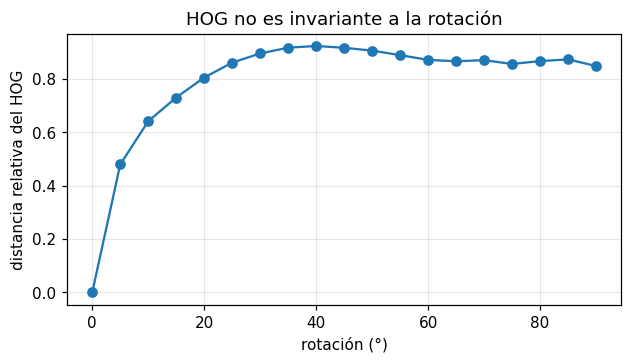

In [10]:
def dist_rel(a, b): return np.linalg.norm(a - b) / np.linalg.norm(a)  # Define la distancia euclidiana relativa normalizada: d_{\text{rel}} = \frac{\

def descriptores(v):  # Computa el descriptor HOG de referencia.
    c, h = hog_manual(v)  # Diccionario que modela 7 perturbaciones físicas controladas.
    return {"Píxeles crudos": v.astype(np.float64).ravel(), "Celdas sin normalizar": c.ravel(), "HOG (bloques L2-Hys)": h}  # Perturbación fotométrica aditiva (cambio de iluminación ambiental).

v = ventana.astype(np.float64)  # Perturbación no lineal de respuesta de sensor (curva gamma).
rampa = np.linspace(0.4, 1.0, v.shape[1])[None, :]  # Perturbación no lineal de oscurecimiento gamma.
transformaciones = {"Brillo +40": np.clip(v + 40, 0, 255), "Contraste ×0.5": v * 0.5,  # Rotación angular leve de 15^\circ.
                    "Gamma 0.6": 255 * (v / 255) ** 0.6, "Iluminación en rampa": v * rampa}  # Rotación angular moderada de 45^\circ.
base = descriptores(v)  # Rotación ortogonal pura de 90^\circ.
tabla = pd.DataFrame({t: {k: dist_rel(base[k], d) for k, d in descriptores(img_t).items()} for t, img_t in transformaciones.items()}).T  # Fin de definición de casos de estrés.
display(tabla.round(3).rename_axis("distancia relativa ↓"))  # Lista acumuladora de distancias relativas.

# Extrae el descriptor HOG del parche perturbado.
gris_ast = cv2.cvtColor(astronauta, cv2.COLOR_RGB2GRAY)  # Calcula y almacena la distancia euclidiana relativa.
region = gris_ast[0:220, 110:300]  # Despliega la tabla comparativa de sensibilidad.
cy, cx = region.shape[0] // 2, region.shape[1] // 2  # Conclusión teórica: la normalización por bloques elimina variaciones lumínicas, pero los bins fijos son inherentemente sensibles a la orientación geométrica del objeto.
def ventana_rotada(ang):  # Función auxiliar que aplica rotación rígida a la región de interés antes de recortar la ventana de prueba.
    M = cv2.getRotationMatrix2D((cx, cy), ang, 1.0)  # Calcula la matriz de transformación afín 2x3 para rotar alrededor del centroide con el ángulo dado.
    r = cv2.warpAffine(region, M, region.shape[::-1])  # Aplica transformación afín cv2.warpAffine sobre la imagen usando interpolación bilineal.
    return r[cy - 64:cy + 64, cx - 32:cx + 32]  # Recorta y devuelve la ventana central normalizada de 128x64 píxeles tras la rotación.
angulos = np.arange(0, 91, 5)  # Define vector de ángulos de evaluación de 0° a 90° con paso regular de 5°.
h0 = hog_manual(ventana_rotada(0))[1]  # Extrae el descriptor HOG de referencia de la ventana orientada a 0°.
plt.figure(figsize=(6.5, 3.2))  # Crea la figura para graficar la curva de degradación de HOG frente a rotación.
plt.plot(angulos, [dist_rel(h0, hog_manual(ventana_rotada(a))[1]) for a in angulos], "o-")  # Traza la distancia relativa euclidiana en función del ángulo de rotación.
plt.xlabel("rotación (°)"); plt.ylabel("distancia relativa del HOG"); plt.title("HOG no es invariante a la rotación")  # Asigna etiquetas a los ejes de rotación y divergencia de características.
plt.grid(alpha=.3); plt.show()  # Añade cuadrícula tenue y despliega la gráfica mostrando la fragilidad de HOG ante rotación.

### 2.4 LBP: un descriptor local de textura
El *Local Binary Pattern* compara cada píxel con sus vecinos y codifica el resultado en bits. Es invariante a cualquier cambio **monótono** de intensidad. Clasificamos parches de tres texturas; los de entrenamiento salen de la mitad izquierda de cada imagen y los de prueba de la mitad derecha, para evitar la fuga espacial que vimos en la Unidad I.

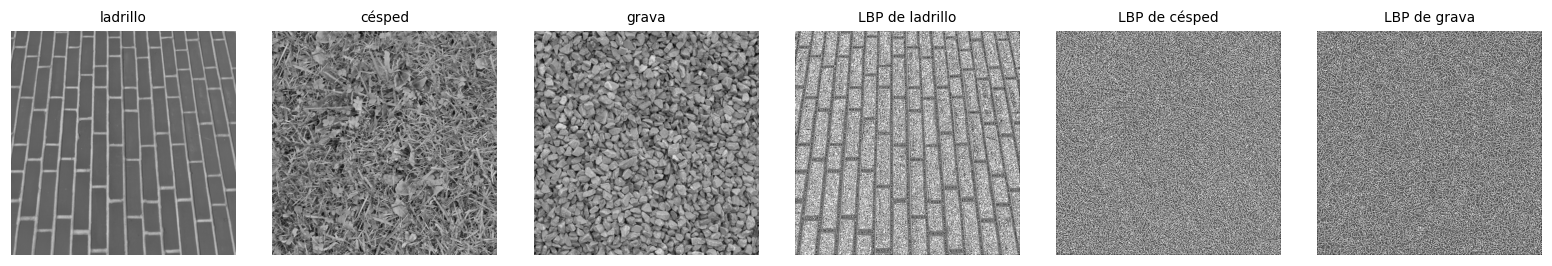

,prueba original,prueba con gamma 0.5,prueba con gamma 2.0
exactitud (3-NN),,,
LBP multiescala,1.000,1.000,1.000
Histograma de intensidad,0.717,0.333,0.333


In [11]:
from skimage.feature import local_binary_pattern  # Importa la función LBP de scikit-image.
from sklearn.neighbors import KNeighborsClassifier  # Diccionario con parches de texturas naturales del dataset estándar de skimage.

texturas = {"ladrillo": data.brick(), "césped": data.grass(), "grava": data.gravel()}  # Textura isotrópica fina estocástica de césped.
mostrar([t for t in texturas.values()] + [local_binary_pattern(t, 8, 1, "uniform") for t in texturas.values()],  # Textura granular no uniforme de grava.
        list(texturas) + [f"LBP de {n}" for n in texturas], cols=6, tam=2.4)  # Fin del conjunto de texturas.

def hist_lbp(p):  # Contenedores para imágenes LBP cuantizadas e histogramas de textura.
    h = []  # Itera sobre cada textura.
    for P, R in [(8, 1), (16, 2), (24, 3)]:  # Calcula el mapa LBP con método `uniform`: agrupa patrones que tienen como máximo 2 transiciones de 0\rightarrow 1 o 1\rightarrow 0 (acumula bordes, esquinas y puntos planos en P+2 = 18 bins).
        l = local_binary_pattern(p, P, R, "uniform")  # Número total de bins uniformes resultantes.
        h.append(np.histogram(l, bins=P + 2, range=(0, P + 2))[0])  # Computa el histograma de frecuencias normalizado como función de densidad de probabilidad.
    h = np.concatenate(h).astype(float)  # Guarda el vector descriptor de textura en el diccionario.
    return h / h.sum()  # Guarda el mapa visual de códigos LBP.

def hist_intensidad(p): return np.histogram(p, bins=32, range=(0, 256))[0] / p.size  # Itera para graficar cada textura y su distribución.

rng = np.random.default_rng(0)  # Fila inferior: histograma LBP característico de la textura.
def parches(img, lado, n, tam=64):  # Configura límites verticales para comparación directa de densidades de probabilidad.
    x0, x1 = (0, 256 - tam) if lado == "izq" else (256, 512 - tam)  # Despliega la comparativa de clasificación de texturas.
    return [img[y:y + tam, x:x + tam] for y, x in zip(rng.integers(0, 512 - tam, n), rng.integers(x0, x1, n))]  # Genera lista de recortes cuadrados de tamaño tam x tam a partir de las coordenadas (y, x).

P_tr, y_tr, P_te, y_te = [], [], [], []  # Inicializa listas vacías para parches de entrenamiento, etiquetas de entrenamiento, prueba y etiquetas de prueba.
for n, img in texturas.items():  # Itera sobre el diccionario de imágenes de textura (ladrillo, césped, madera, etc.).
    P_tr += parches(img, "izq", 40); y_tr += [n] * 40  # Extrae 40 parches de la mitad izquierda para entrenamiento y añade sus etiquetas de clase.
    P_te += parches(img, "der", 40); y_te += [n] * 40  # Extrae 40 parches de la mitad derecha para prueba (conjunto no solapado) y añade sus etiquetas.
gamma = lambda p, g: (255 * (p / 255) ** g).astype(np.uint8)  # Función de transformación gamma no lineal para simular distorsiones fotométricas.

filas = {}  # Diccionario para compilar la exactitud de clasificación de texturas bajo variaciones lumínicas.
for nombre, f in [("LBP multiescala", hist_lbp), ("Histograma de intensidad", hist_intensidad)]:  # Itera sobre el descriptor LBP y el histograma directo de intensidades.
    knn = KNeighborsClassifier(3).fit([f(p) for p in P_tr], y_tr)  # Entrena clasificador 3-NN sobre los parches de entrenamiento.
    filas[nombre] = {"prueba original": knn.score([f(p) for p in P_te], y_te),  # Evalúa exactitud en prueba sobre imágenes normales sin perturbar.
                     "prueba con gamma 0.5": knn.score([f(gamma(p, 0.5)) for p in P_te], y_te),  # Evalúa ante sobreexposición lumínica demostrando la invarianza de LBP frente a la caída del histograma.
                     "prueba con gamma 2.0": knn.score([f(gamma(p, 2.0)) for p in P_te], y_te)}  # Evalúa ante subexposición lumínica severa.
pd.DataFrame(filas).T.round(3).rename_axis("exactitud (3-NN)")  # Despliega la tabla comparativa de robustez fotométrica.

### 2.5 Puntos de interés: esquinas de Harris y Shi-Tomasi
Un punto en una zona uniforme no se puede reconocer en otra imagen; una esquina sí. Harris mide cuánto cambia la intensidad al desplazar una ventana en **todas** las direcciones. Esta es la base de los detectores del Ejemplo 4.

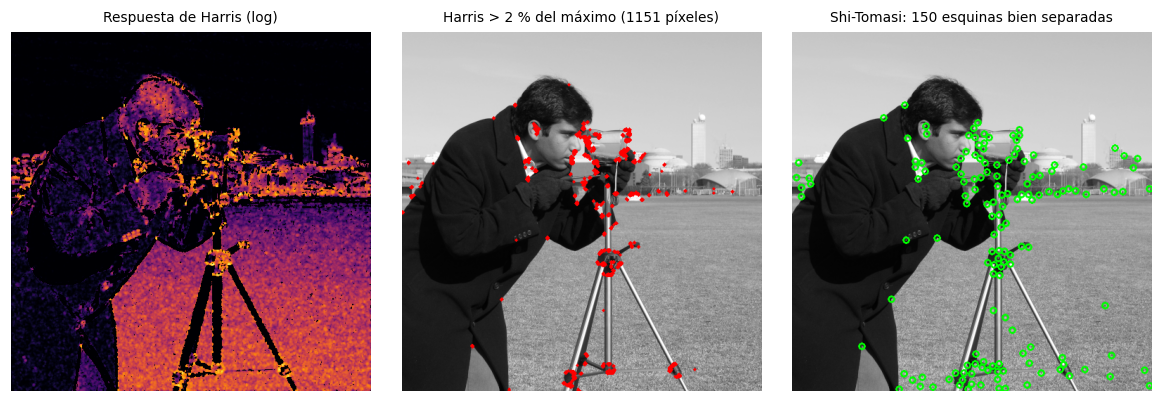

In [12]:
g = np.float32(camara)  # Convierte la imagen a coma flotante para cómputo de derivadas.
harris = cv2.cornerHarris(g, blockSize=3, ksize=3, k=0.04)  # Detector de Harris: calcula la respuesta R = \det(M) - k \cdot (\text{tr}(M))^2 usando ventana de 3x 3, kernel de Sobel 3x 3 y constante empírica k=0.04.
esquinas_st = cv2.goodFeaturesToTrack(camara, maxCorners=150, qualityLevel=0.02, minDistance=8)  # Detector de Shi-Tomasi: busca las mejores 150 esquinas evaluando R = \min(\lambda_1, \lambda_2) con umbral de calidad relativo (2\% del máximo autovalor) y distancia euclidiana mínima de 8 píxeles entre esquinas (supresión de no máximos espacial integrada).

vis_h = cv2.cvtColor(camara, cv2.COLOR_GRAY2RGB)  # Umbraliza la respuesta de Harris al 2\% del valor máximo global.
yx = np.argwhere(harris > 0.02 * harris.max())  # Dibuja puntos rojos en las esquinas de Harris detectadas.
for y, x in yx: cv2.circle(vis_h, (int(x), int(y)), 2, (255, 0, 0), -1)  # Prepara lienzo de color para visualizar esquinas de Shi-Tomasi.
vis_st = cv2.cvtColor(camara, cv2.COLOR_GRAY2RGB)  # Dibuja círculos verdes con radio 4 píxeles en las coordenadas de Shi-Tomasi.
for x, y in esquinas_st.reshape(-1, 2): cv2.circle(vis_st, (int(x), int(y)), 4, (0, 255, 0), 2)  # Llama a visualización para comparar la respuesta logarítmica de Harris, los puntos de Harris y las esquinas bien espaciadas de Shi-Tomasi.

mostrar([np.log1p(np.maximum(harris, 0)), vis_h, vis_st],  # Invoca función mostrar() pasando el mapa de respuesta de Harris en escala logarítmica y visualizaciones con esquinas.
        ["Respuesta de Harris (log)", f"Harris > 2 % del máximo ({len(yx)} píxeles)", f"Shi-Tomasi: {len(esquinas_st)} esquinas bien separadas"], cmap="inferno", tam=3.6)  # Títulos descriptivos indicando los umbrales relativos aplicados en Harris y Shi-Tomasi.

**Para discutir en clase**
1. En 2.3, ¿qué transformación resuelven las celdas sin normalizar y cuál no? ¿Qué aporta exactamente la normalización por bloques?
2. HOG funcionó muy bien para detectar peatones de pie. ¿Por qué funcionaría peor para detectar peatones en fotos tomadas desde un dron?
3. ¿En qué problema de su dominio la textura (LBP) sería más informativa que la forma (HOG)?

---
# Ejemplo 3 · Segmentación de imágenes (umbralización y clustering)

**Objetivo.** Implementar Otsu, comparar umbral global vs adaptativo con métricas sobre verdad de terreno, usar K-means con criterio para elegir K y el espacio de características, y separar objetos que se tocan con watershed.

### 3.1 Otsu desde cero
Otsu elige el umbral `t` que maximiza la varianza **entre clases** `σ²_B(t) = [μ_T·ω(t) − μ(t)]² / [ω(t)·(1 − ω(t))]`.

Umbral de Otsu → manual: 107 · OpenCV: 107 · scikit-image: 107


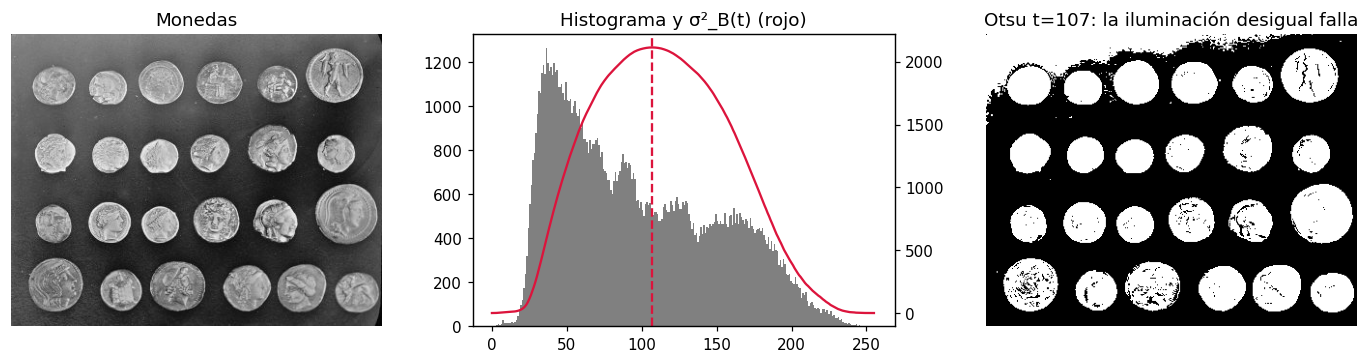

In [13]:
def otsu_manual(img):  # Define la función que computa analíticamente el umbral óptimo de Otsu para una imagen dada.
    p = np.bincount(img.ravel(), minlength=256) / img.size  # Calcula el histograma normalizado de 256 niveles representando la función de masa de probabilidad p(i) = \frac{n_i}{N}.
    omega = np.cumsum(p); mu = np.cumsum(p * np.arange(256)); mu_T = mu[-1]  # Calcula la probabilidad acumulada de clase fondo \omega_0(t) = \sum_{i=0}^t p_i, la media acumulada \mu(t) = \sum_{i=0}^t i \cdot p_i y la media global total \mu_T = \sum_{i=0}^{255} i \cdot p_i.
    sigma_b = (mu_T * omega - mu) ** 2 / (omega * (1 - omega) + 1e-12)  # Fórmula cerrada vectorizada de la varianza inter-clase: sigma_B^2(t) = \frac{(\mu_T \omega_0(t) - \mu(t))^2}{\omega_0(t)(1 - \omega_0(t))}, añadiendo \epsilon = 10^{-12} para evitar división por cero.
    return int(np.argmax(sigma_b)), sigma_b  # Retorna el umbral óptimo t^* = \arg\max_t sigma_B^2(t) que maximiza la separabilidad de las clases y la curva completa de varianzas.

t_manual, curva = otsu_manual(monedas)  # Ejecuta Otsu nativo de OpenCV (el argumento inicial 0 se ignora ya que `THRESH_OTSU` calcula el umbral).
t_cv, bin_cv = cv2.threshold(monedas, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)  # Ejecuta Otsu en scikit-image retornando el umbral óptimo directamente.
t_sk = filters.threshold_otsu(monedas)  # Imprime la coincidencia exacta de los 3 cálculos (valor idéntico entero).
print(f"Umbral de Otsu → manual: {t_manual} · OpenCV: {t_cv:.0f} · scikit-image: {t_sk}")  # Inicializa figura de 3 paneles para visualización de histograma y resultado.

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))  # Panel 2: histograma de intensidades en gris con segundo eje vertical gemelo (`twinx`).
axes[0].imshow(monedas, cmap="gray"); axes[0].axis("off"); axes[0].set_title("Monedas")  # Grafica la parábola de varianza inter-clase sigma_B^2(t) en rojo y traza la línea vertical punteada en el máximo t^*.
axes[1].hist(monedas.ravel(), bins=256, range=(0, 256), color="gray"); ax2 = axes[1].twinx()  # Título del panel de distribución estadística.
ax2.plot(curva, color="crimson"); axes[1].axvline(t_manual, color="crimson", ls="--")  # Panel 3: máscara binarizada global de Otsu, evidenciando que un único umbral global fracasa al segmentar monedas en fondos con iluminación no uniforme.
axes[1].set_title("Histograma y σ²_B(t) (rojo)")  # Despliega los gráficos.
axes[2].imshow(bin_cv, cmap="gray"); axes[2].axis("off"); axes[2].set_title(f"Otsu t={t_manual}: la iluminación desigual falla")  # Visualiza la binarización de referencia obtenida con cv2.threshold y oculta los ejes de coordenadas.
plt.tight_layout(); plt.show()  # Ajusta la distribución espacial de los subgráficos y despliega la figura interactiva.

### 3.2 Umbral global vs adaptativo en un documento con sombra
Simulamos la foto de una hoja de respuestas con una sombra (caso del documento de la unidad: digitalizar evaluaciones). Conocemos exactamente qué píxeles son tinta, así que medimos F1.

                      F1 de la tinta
Otsu global                    0.335
Adaptativo gaussiano           0.955
Sauvola (skimage)              0.946


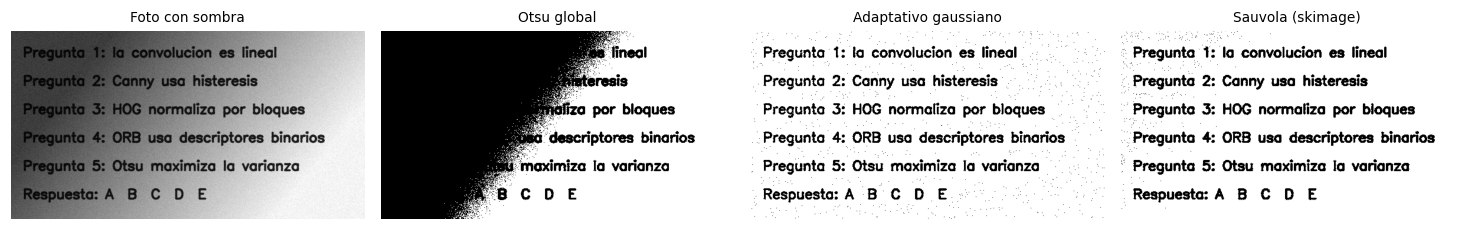

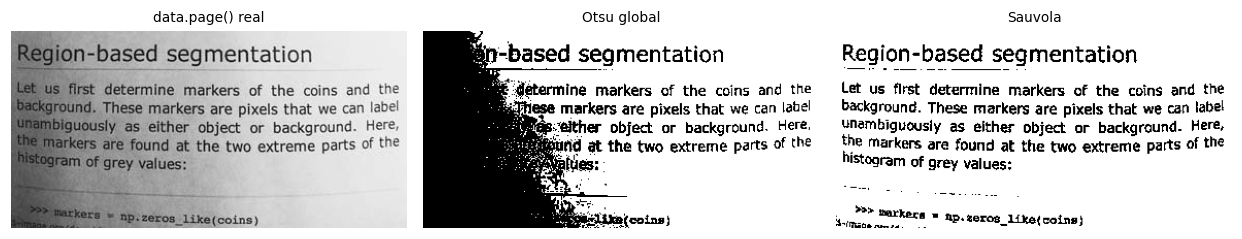

In [14]:
limpia = np.full((320, 600), 245, np.uint8)  # Inicializa lienzo de papel blanco claro de 320x 600 píxeles.
lineas = ["Pregunta 1: la convolucion es lineal", "Pregunta 2: Canny usa histeresis",  # Lista con 6 líneas de texto representativo de una prueba académica.
          "Pregunta 3: HOG normaliza por bloques", "Pregunta 4: ORB usa descriptores binarios",  # Continuación de enunciados.
          "Pregunta 5: Otsu maximiza la varianza", "Respuesta: A  B  C  D  E"]  # Opciones de respuesta final.
for i, t in enumerate(lineas):  # Itera imprimiendo cada línea de texto en el lienzo.
    cv2.putText(limpia, t, (20, 45 + i * 48), cv2.FONT_HERSHEY_SIMPLEX, 0.75, 30, 2, cv2.LINE_AA)  # Dibuja tipografía oscura (intensidad 30) con espaciado vertical regular de 48 píxeles.
gt_tinta = limpia < 128  # Genera la máscara binaria exacta de la tinta como Verdad de Terreno (*Ground Truth*).

yy, xx = np.mgrid[0:320, 0:600]  # Modela un gradiente continuo de sombra proyectada que oscurece severamente la esquina superior izquierda (luminancia cae al 25\%).
iluminacion = np.clip((xx + 0.8 * yy) / 700, 0.25, 1.0)  # Multiplica la reflectancia del documento por el campo de iluminación y añade ruido gaussiano aditivo.
foto = np.clip(limpia * iluminacion + np.random.default_rng(3).normal(0, 6, limpia.shape), 0, 255).astype(np.uint8)  # Diccionario que encapsula los tres algoritmos binarizadores bajo evaluación.

metodos = {  # Método 2: Umbral local adaptativo donde el umbral T(x,y) es el promedio ponderado gaussiano de una vecindad de 31x 31 píxeles menos la constante C=15.
    "Otsu global":            lambda im: im < filters.threshold_otsu(im),  # Método 3: Umbral local de Sauvola formulado específicamente para documentos: T(x,y) = m(x,y) \cdot [1 + k \cdot (\frac{s(x,y)}{R} - 1)] con k=0.2 y ventana de 31 píxeles.
    "Adaptativo gaussiano":   lambda im: cv2.adaptiveThreshold(im, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 15) == 0,  # Fin de métodos.
    "Sauvola (skimage)":      lambda im: im < filters.threshold_sauvola(im, window_size=31, k=0.2),  # Aplica cada algoritmo sobre la imagen fotográfica degradada.
}  # Calcula y despliega la métrica armónica F_1 frente a la tinta real (evidencia el colapso de Otsu global frente a > 0.85 en adaptativos).
res = {n: f(foto) for n, f in metodos.items()}  # Muestra la foto de entrada y las tres máscaras de texto recuperadas.
print(pd.Series({n: f1_mascara(r, gt_tinta) for n, r in res.items()}).round(3).to_frame("F1 de la tinta"))  # Carga la imagen real estándar `page()` con viñeteado óptico y sombras severas.
mostrar([foto] + [~r for r in res.values()], ["Foto con sombra"] + list(res), cols=4, tam=3.4)  # Compara Otsu global frente a Sauvola sobre la imagen real.

pagina = data.page()  # Carga la imagen estándar 'page' de scikit-image: texto impreso con iluminación no uniforme y sombras.
mostrar([pagina, pagina > filters.threshold_otsu(pagina), pagina > filters.threshold_sauvola(pagina, window_size=25)],  # Invoca función mostrar() comparando la página original, la falla de Otsu global y el éxito de Sauvola local.
        ["data.page() real", "Otsu global", "Sauvola"], tam=3.8)  # Etiquetas descriptivas que evidencian la superioridad del umbral adaptativo local en iluminación inhomogénea.

### 3.3 Umbralización multinivel
Cuando hay más de dos poblaciones de intensidad, multi-Otsu busca `K−1` umbrales a la vez.

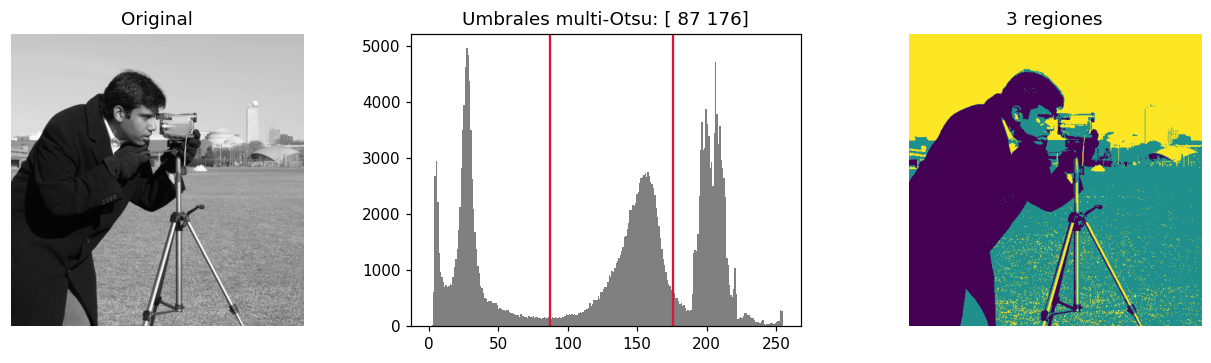

In [15]:
umbrales = filters.threshold_multiotsu(camara, classes=3)  # Aplica multi-Otsu sobre la imagen de cámara para encontrar 2 umbrales que separan la distribución en 3 clases óptimas.
regiones = np.digitize(camara, bins=umbrales)  # Clasifica cada píxel en las clases \{0, 1, 2\} según los intervalos definidos por los umbrales.
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))  # Crea lienzo de 3 paneles para imagen original, histograma multiumbralizado y mapa de regiones.
axes[0].imshow(camara, cmap="gray"); axes[0].set_title("Original")  # Panel 1: imagen monocromática original.
axes[1].hist(camara.ravel(), bins=256, color="gray")  # Panel 2: histograma de intensidades global.
for t in umbrales: axes[1].axvline(t, color="crimson")  # Traza líneas verticales rojas en los umbrales calculados por multi-Otsu.
axes[1].set_title(f"Umbrales multi-Otsu: {umbrales}")  # Título que reporta los valores cuantitativos de corte.
axes[2].imshow(regiones, cmap="viridis"); axes[2].set_title("3 regiones")  # Panel 3: mapa de segmentación categórica coloreado con el mapa perceptual viridis.
for ax in (axes[0], axes[2]): ax.axis("off")  # Oculta marcas de graduación espacial.
plt.tight_layout(); plt.show()  # Despliega la figura multiumbral.

### 3.4 K-means: elegir K y el espacio de características
K-means agrupa píxeles que se **parecen numéricamente**; no sabe qué es una "taza" o un "plato". Por eso importa qué números le damos: RGB, Lab (más cercano a la percepción) o Lab + posición (x, y), que favorece regiones compactas.

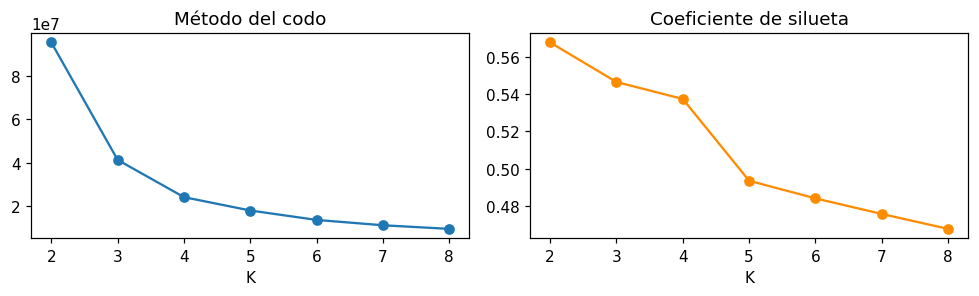

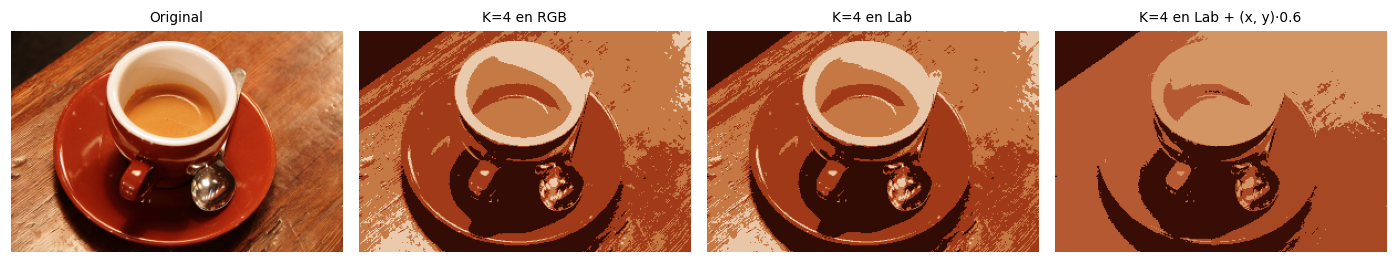

In [16]:
from sklearn.metrics import silhouette_score  # Importa la métrica de coeficiente de silueta de scikit-learn.

cafe = data.coffee()  # Reduce la resolución a 300x 200 píxeles mediante interpolación por área para acelerar la computación de clusters.
pequena = cv2.resize(cafe, (300, 200), interpolation=cv2.INTER_AREA)  # Convierte de RGB al espacio perceptual CIELAB (donde la distancia euclidiana modela fielmente la percepción humana de diferencias cromáticas \Delta E).
lab = cv2.cvtColor(pequena, cv2.COLOR_RGB2LAB).astype(np.float32)  # Extrae dimensiones de altura y anchura.
h, w = lab.shape[:2]  # Genera mallas de coordenadas espaciales normalizadas.
yy, xx = np.mgrid[0:h, 0:w]  # Define función envolvente para ejecutar K-Means nativo de OpenCV optimizado en C++.

def kmeans(X, k, semilla=0):  # Criterios de convergencia de Lloyd: detenerse si se alcanzan 50 iteraciones o si el desplazamiento de centroides es menor a 0.5.
    cv2.setRNGSeed(semilla)  # Ejecuta K-Means con 5 reinicios aleatorios y selección de centros iniciales optimizada según el algoritmo k-means++.
    crit = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 50, 0.5)  # Retorna la suma de distancias al cuadrado (compacidad/inercia), las etiquetas por píxel y los centroides finales.
    compacidad, etiquetas, centros = cv2.kmeans(X.astype(np.float32), k, None, crit, 5, cv2.KMEANS_PP_CENTERS)  # Aplana la matriz de imagen a una nube de puntos Nx 3 en el espacio (L^*, a^*, b^*).
    return compacidad, etiquetas.ravel(), centros  # Submuestrea aleatoriamente 3,000 píxeles para calcular la silueta sin sobrecargar memoria O(N^2).

X_lab = lab.reshape(-1, 3)  # Itera sobre valores de K desde 2 hasta 8 clusters.
idx = np.random.default_rng(0).choice(len(X_lab), 3000, replace=False)  # Ejecuta K-Means para el K actual.
filas = []  # Computa la inercia interna y la métrica de silueta.
for k in range(2, 9):  # Estructura los resultados en DataFrame.
    comp, etq, _ = kmeans(X_lab, k)  # Crea gráficos gemelos: método del codo y curva de silueta.
    filas.append({"K": k, "inercia": comp, "silueta (muestra)": silhouette_score(X_lab[idx], etq[idx])})  # Curva de inercia decreciente: identifica el punto de inflexión o 'codo'.
seleccion = pd.DataFrame(filas)  # Curva de silueta: identifica el K que maximiza la cohesión intra-cluster y separación inter-cluster.
fig, ax = plt.subplots(1, 2, figsize=(9, 2.8))  # Despliega los gráficos analíticos.
ax[0].plot(seleccion.K, seleccion.inercia, "o-"); ax[0].set_title("Método del codo"); ax[0].set_xlabel("K")  # Fija K=4 clusters representativos (café oscuro, espuma/granos medios, taza blanca, fondo).
ax[1].plot(seleccion.K, seleccion["silueta (muestra)"], "o-", color="darkorange"); ax[1].set_title("Coeficiente de silueta"); ax[1].set_xlabel("K")  # Espacio 1: nubes de color RGB de 3 dimensiones.
plt.tight_layout(); plt.show()  # Espacio 2: nubes perceptuales CIELAB de 3 dimensiones.

K = 4  # Listas para visualización comparativa de segmentaciones.
espacios = {"RGB": pequena.reshape(-1, 3).astype(np.float32),  # Itera sobre los 3 espacios de características.
            "Lab": X_lab,  # Ejecuta K-Means en el espacio dimensional actual.
            "Lab + (x, y)·0.6": np.column_stack([X_lab, 0.6 * xx.ravel(), 0.6 * yy.ravel()])}  # Reemplaza cada píxel por el color promedio RGB de su cluster asignado (cuantización de color).
imgs, tits = [pequena], ["Original"]  # Reconstruye la imagen segmentada.
for n, X in espacios.items():  # Despliega original frente a segmentaciones en RGB, Lab y Lab espacial.
    _, etq, _ = kmeans(X, K)  # Aplica clustering K-Means sobre la matriz de características X agrupando los píxeles en K clústeres.
    medias = np.array([pequena.reshape(-1, 3)[etq == c].mean(0) for c in range(K)])  # Calcula el color RGB promedio de los píxeles asignados a cada uno de los clústeres identificados.
    imgs.append(medias[etq].reshape(pequena.shape).astype(np.uint8)); tits.append(f"K={K} en {n}")  # Reconstruye la imagen segmentada sustituyendo cada píxel por el centroide de color de su clúster.
mostrar(imgs, tits, cols=4, tam=3.2)  # Despliega cuadrícula con las segmentaciones resultantes para diferentes valores de K y restricciones espaciales.

### 3.5 Watershed: separar objetos que se tocan
Si dos objetos se tocan, cualquier umbral los une en una sola región. Watershed trata la **transformada de distancia** como un relieve e "inunda" desde un marcador por objeto. Usamos una escena sintética para conocer el número real de objetos y medir IoU por objeto.

Objetos reales: 10 · componentes conectados: 4 · watershed: 10
IoU medio por objeto (watershed): 0.936


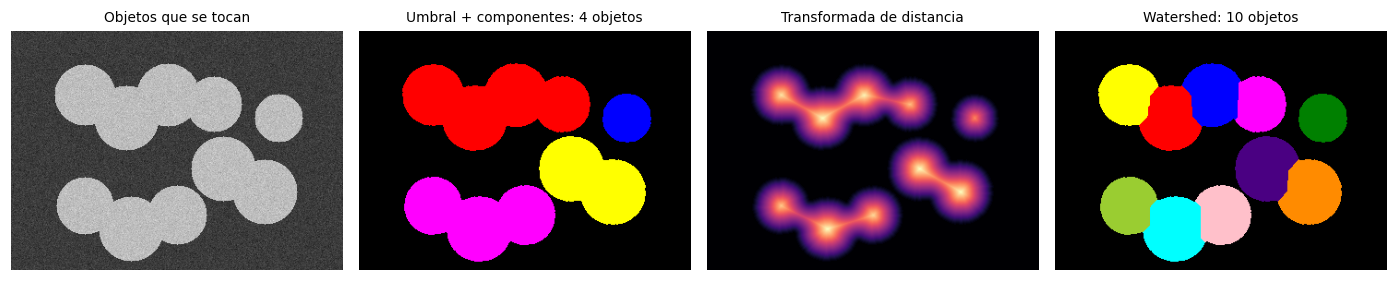

In [17]:
from skimage.feature import peak_local_max  # Importa detector de máximos locales de scikit-image.
from scipy.optimize import linear_sum_assignment  # Importa el algoritmo húngaro para asignación óptima de máxima correspondencia bipartita.

rng = np.random.default_rng(4)  # Dimensiones del lienzo sintético de prueba: 260 filas por 360 columnas.
Hs, Ws = 260, 360  # Lista con las coordenadas de centro de 10 discos circulares ubicados con solapamientos mutuos deliberados.
centros = [(80, 70), (125, 95), (170, 70), (80, 190), (130, 215), (230, 150), (275, 175), (290, 95), (220, 80), (180, 200)]  # Radios aleatorios entre 26 y 35 píxeles para cada disco.
radios = rng.integers(26, 36, len(centros))  # Matriz de etiquetas para la Verdad de Terreno (*Ground Truth*).
gt_etq = np.zeros((Hs, Ws), np.int32)  # Matriz de distancias relativas para resolver la frontera de solapamiento mediante el disco más próximo.
dist_min = np.full((Hs, Ws), np.inf)  # Malla bidimensional de coordenadas espaciales.
yy, xx = np.mgrid[0:Hs, 0:Ws]  # Itera sintetizando cada uno de los 10 objetos individuales.
for i, ((cx, cy), r) in enumerate(zip(centros, radios), start=1):  # Calcula la distancia radial normalizada al centroide del disco.
    d = np.hypot(xx - cx, yy - cy) / r  # Píxeles que caen dentro del radio del disco y pertenecen prioritariamente a su núcleo.
    dentro = (d <= 1) & (d < dist_min)  # Asigna la etiqueta del objeto i en la verdad de terreno.
    gt_etq[dentro] = i; dist_min[dentro] = d[dentro]  # Genera la imagen visual: discos claros (190) sobre fondo oscuro (60) con ruido gaussiano aditivo (sigma=10).
img_toque = np.clip(np.where(gt_etq > 0, 190, 60) + rng.normal(0, 10, (Hs, Ws)), 0, 255).astype(np.uint8)  # Binarización previa de Otsu: los objetos solapados se fusionan erróneamente en una sola masa conexa gigante.

binaria = cv2.GaussianBlur(img_toque, (5, 5), 0) > filters.threshold_otsu(img_toque)  # Transformada de distancia euclidiana exacta (*Exact Euclidean Distance Transform*, EDT): asigna a cada píxel interior su distancia euclidiana al fondo más cercano.
cc = measure.label(binaria)  # Localiza las cumbres o crestas de distancia (núcleos interiores profundos) forzando una separación mínima de 15 píxeles entre picos.

dist = ndi.distance_transform_edt(binaria)  # Aplica la transformada de Watershed sobre la superficie topográfica invertida -dist: inunda las cuencas desde los marcadores y levanta diques divisorios donde se encuentran los frentes de inundación.
picos = peak_local_max(dist, min_distance=15, labels=cc, exclude_border=False)  # Función para evaluar la precisión de segmentación objeto por objeto emparejando regiones predichas con las reales.
marcadores = np.zeros_like(cc); marcadores[tuple(picos.T)] = np.arange(1, len(picos) + 1)  # Extrae listas de identificadores de objetos omitiendo el fondo (0).
ws = segmentation.watershed(-dist, marcadores, mask=binaria)  # Construye la matriz de solapamiento IoU de dimensiones N_{\text{pred}} x N_{\text{gt}}.

def iou_por_objeto(pred, gt):  # Retorna el vector de IoUs de los pares óptimamente emparejados.
    ids_p, ids_g = np.unique(pred)[1:], np.unique(gt)[1:]  # Contrasta el recuento: evidencia que `cc` detecta menos objetos por fusión, mientras que `watershed` recupera con éxito los 10 centros individuales.
    M = np.array([[iou(pred == p, gt == g) for g in ids_g] for p in ids_p])  # Imprime la fidelidad espacial media de segmentación (IoU > 0.90).
    fi, co = linear_sum_assignment(-M)  # Despliega los 4 paneles del proceso.
    return M[fi, co]  # Títulos demostrativos del poder del Watershed para resolver oclusiones y contactos en visión industrial y microscopía.

print(f"Objetos reales: {len(centros)} · componentes conectados: {cc.max()} · watershed: {ws.max()}")  # Imprime el número de objetos reales conocidos frente a las componentes conexas ingenuas detectadas.
print(f"IoU medio por objeto (watershed): {iou_por_objeto(ws, gt_etq).mean():.3f}")  # Calcula y reporta el IoU medio por objeto obtenido mediante el algoritmo de Watershed con marcadores.
mostrar([cv2.cvtColor(img_toque, cv2.COLOR_GRAY2RGB), color.label2rgb(cc, bg_label=0), dist, color.label2rgb(ws, bg_label=0)],  # Invoca función mostrar() con la imagen de círculos en contacto y las máscaras segmentadas.
        ["Objetos que se tocan", f"Umbral + componentes: {cc.max()} objetos", "Transformada de distancia", f"Watershed: {ws.max()} objetos"], cmap="magma", tam=3.2)  # Títulos descriptivos resaltando la separación exitosa de objetos fusionados mediante distancia euclidiana.

**Para discutir en clase**
1. En 3.2, ¿por qué el umbral global falla aunque Otsu sea "óptimo"? ¿Óptimo bajo qué supuesto?
2. En 3.4, el codo y la silueta pueden sugerir K distintos. ¿Qué criterio del problema real usarían para decidir?
3. Watershed necesita un marcador por objeto. ¿Qué ocurre si `min_distance` es demasiado pequeño o demasiado grande?

---
# Ejemplo 4 · Detección de características (SIFT, SURF, ORB)

**Objetivo.** Comparar detectores y descriptores de forma cuantitativa. La clave es crear la segunda imagen con una **homografía conocida**: así sabemos exactamente dónde debe caer cada punto y podemos contar cuántos emparejamientos son correctos.

### 4.1 Detectar y describir
En las imágenes, el tamaño de cada círculo es la escala del punto clave y el radio dibujado indica su orientación.
SIFT y SURF producen descriptores de números reales (se comparan con distancia euclidiana); ORB, AKAZE y BRISK producen descriptores binarios (distancia de Hamming, mucho más rápida). SURF está patentado y solo existe en compilaciones de OpenCV con módulos *non-free*, que no es el caso de Colab: el código lo intenta y lo informa si no está.

In [18]:
import cv2  # Importa OpenCV para acceso a los submódulos de descriptores locales y emparejadores de características.

print("Versión de OpenCV:", cv2.__version__)  # Nota histórica: la patente de David Lowe venció en marzo de 2020, por lo que SIFT ahora forma parte del núcleo libre de OpenCV.

try:  # Clasificación de licencias: ORB, AKAZE y BRISK son libres de regalías para uso comercial sin restricciones.
# Documenta la sintaxis recomendada por la API de OpenCV 4.x mediante patrón fábrica .create().
    akaze = cv2.AKAZE.create()  # Inicializa el detector y descriptor invariante multiescala AKAZE.
    print("¡Éxito! cv2.AKAZE se ha inicializado correctamente.")  # Imprime mensaje de confirmación de inicialización correcta de AKAZE.
except AttributeError:  # Captura excepción en caso de ausencia de los símbolos en la compilación de OpenCV instalada.
    print("Error: No se pudo encontrar el método AKAZE. Verifica tu instalación.")  # Imprime mensaje diagnóstico si el método de inicialización no fue encontrado.


Versión de OpenCV: 4.14.0
¡Éxito! cv2.AKAZE se ha inicializado correctamente.


In [19]:
import sys  # Importa el módulo del sistema para inspección de módulos cargados.
import cv2  # Evalúa reflexivamente si la biblioteca OpenCV contiene el espacio de nombres `xfeatures2d`.

print("Ejecutable de Python:", sys.executable)  # Imprime la ruta absoluta del intérprete de Python en ejecución.
print("Ruta de OpenCV:", cv2.__file__)  # Imprime la ruta del módulo compilado binario de OpenCV cargado en memoria.
print("Versión de OpenCV:", cv2.__version__)  # Imprime la cadena de versión exacta de OpenCV.

Ejecutable de Python: /usr/bin/python3
Ruta de OpenCV: /usr/local/lib/python3.13/dist-packages/cv2/__init__.py
Versión de OpenCV: 4.14.0


In [ ]:
# Comando mágico de Jupyter comentado para instalar la rueda completa con soporte de algoritmos contrib.

,método,puntos,descriptor,bytes por punto,tiempo (ms)
0,SIFT,1105,128 × float32,512,112.3
1,ORB,2000,32 × uint8,32,527.2
2,AKAZE,870,61 × uint8,61,47.2
3,BRISK,2008,64 × uint8,64,43.2


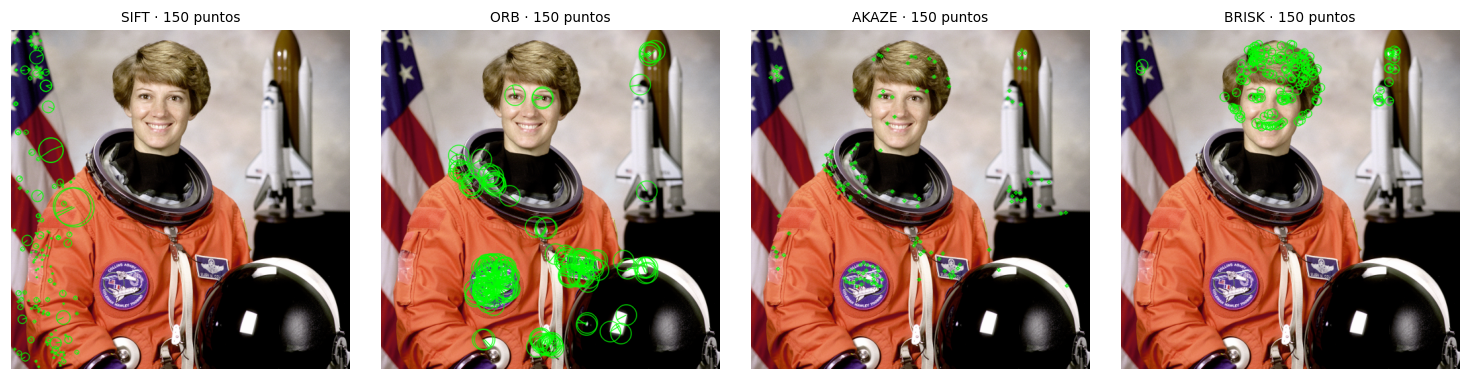

In [20]:
def crear_detectores():  # Define la función constructora que retorna un diccionario con los extractores disponibles.
    d = {  # Diccionario contenedor indexado por el nombre del algoritmo.
        "SIFT": cv2.SIFT_create(nfeatures=2000),  # SIFT: detector basado en DoG (Diferencia de Gaussianas) y descriptor flotante de 128 dimensiones con norma L2.
        "ORB": cv2.ORB_create(nfeatures=2000),  # ORB: detector FAST con orientación por momentos angulares y descriptor binario rBRIEF de 256 bits con norma Hamming.
        "AKAZE": cv2.AKAZE_create(),  # AKAZE: espacio de escalas de difusión no lineal de Fedkiw (preserva bordes) y descriptor binario M-LDB.
        "BRISK": cv2.BRISK_create()  # BRISK: muestreo concéntrico circular en pirámide FAST, descriptor binario de 512 bits.
    }  # Bloque de captura de errores para intentar instanciar SURF.

    try:  # Captura excepciones si el módulo no libre no está compilado.
        d["SURF"] = cv2.xfeatures2d.SURF_create(400)  # Omite silenciosamente la adición de SURF.
    except:  # Retorna el mapa con los algoritmos instanciados.
        pass  # Ejecuta la inicialización global de los detectores en memoria.

    return d  # Devuelve el diccionario que asocia el nombre de cada algoritmo con su instancia inicializada.

def norma(nombre): return cv2.NORM_L2 if nombre in ("SIFT", "SURF") else cv2.NORM_HAMMING  # Función auxiliar que retorna cv2.NORM_L2 para descriptores reales (SIFT/SURF) y cv2.NORM_HAMMING para binarios (ORB/AKAZE/BRISK).

detectores = crear_detectores()  # Instancia la fábrica completa de detectores y descriptores invariantes.
gris = cv2.cvtColor(astronauta, cv2.COLOR_RGB2GRAY)  # Convierte la imagen de prueba 'astronauta' a escala de grises para la extracción de puntos clave.
filas, vis = [], []  # Inicializa listas acumuladoras para métricas tabulares e imágenes de visualización de puntos de interés.
for n, det in detectores.items():  # Itera sobre los detectores instanciados (SIFT, ORB, AKAZE, BRISK).
    t0 = time.perf_counter(); kp, des = det.detectAndCompute(gris, None); t = (time.perf_counter() - t0) * 1000  # Mide latencia de extracción de puntos clave y descriptores.
    filas.append({"método": n, "puntos": len(kp), "descriptor": f"{des.shape[1]} × {des.dtype}",  # Registra el algoritmo, cantidad de puntos detectados y longitud del vector descriptor.
                  "bytes por punto": des.shape[1] * des.itemsize, "tiempo (ms)": round(t, 1)})  # Registra memoria consumida por descriptor en bytes y tiempo de ejecución en milisegundos.
    vis.append(cv2.drawKeypoints(astronauta, kp[:150], None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS))  # Dibuja los primeros 150 puntos clave con círculos proporcionales a su escala y orientación.
display(pd.DataFrame(filas))  # Despliega la tabla cuantitativa comparando eficiencia y dimensiones de cada método.
mostrar(vis, [f"{n} · 150 puntos" for n in detectores], tam=3.4)  # Visualiza los puntos clave detectados en cada algoritmo.

### 4.2 Emparejamiento con verdad de terreno
Transformamos la imagen con una homografía `H` conocida (rotación, escala y perspectiva) y además cambiamos brillo y añadimos ruido. Un emparejamiento es **correcto** si al proyectar el punto de la imagen 1 con `H` cae a menos de 3 píxeles de su pareja en la imagen 2.

In [21]:
def homografia(forma, angulo=0, escala=1.0, perspectiva=0.0, semilla=0):  # Genera una matriz de homografía 3x 3 combinando rotación euclidiana, factor de escala y componentes de perspectiva.
    h, w = forma  # Extrae dimensiones de altura y anchura de la imagen.
    esquinas = np.float32([[0, 0], [w, 0], [w, h], [0, h]])  # Punto central de rotación y escalado afín.
    R = cv2.getRotationMatrix2D((w / 2, h / 2), angulo, escala)  # Construye la matriz afín 2x 3 de rotación y escala en torno al centro.
    destino = cv2.transform(esquinas[None], R)[0]  # Inicializa matriz de homografía proyectiva identidad de 3x 3.
    destino += np.random.default_rng(semilla).uniform(-1, 1, destino.shape).astype(np.float32) * perspectiva * w  # Incrusta las filas afines de rotación y escala en las dos primeras filas de H.
    return cv2.getPerspectiveTransform(esquinas, destino)  # Introduce deformación de fuga proyectiva en el eje horizontal (h_{31}).

def transformar(img, H, fotometrico=True, semilla=0):  # Retorna la homografía proyectiva exacta de verdad de terreno (H_{\text{gt}}).
    out = cv2.warpPerspective(img, H, img.shape[::-1])  # Función maestra de correspondencia: ejecuta detección, emparejamiento KNN k=2, filtro de Lowe, RANSAC y verificación proyectiva.
    if fotometrico:  # Detecta puntos clave y computa descriptores sobre la imagen 1.
        rng = np.random.default_rng(semilla)  # Detecta puntos clave y computa descriptores sobre la imagen 2.
        out = np.clip(out * 0.75 + 25 + rng.normal(0, 5, out.shape), 0, 255).astype(np.uint8)  # Validación defensiva: verifica que existan al menos 4 puntos para estimar homografías.
    return out  # Retorna ceros si no hay características suficientes.

def emparejar(nombre, det, img1, img2, H_gt=None, razon=0.75, usar_razon=True):  # Instancia emparejador de fuerza bruta (*Brute-Force Matcher*) con la métrica adecuada.
    t0 = time.perf_counter()  # Busca los 2 vecinos más cercanos para cada descriptor de consulta en la imagen 2.
    kp1, d1 = det.detectAndCompute(img1, None); kp2, d2 = det.detectAndCompute(img2, None)  # Lista de correspondencias depuradas.
    if d1 is None or d2 is None or len(kp1) < 2 or len(kp2) < 2:  # Itera sobre cada par de candidatos vecinos.
        return {"método": nombre, "emparejamientos": 0, "correctos": 0}  # Verifica que se encontraron exactamente 2 vecinos.
    bf = cv2.BFMatcher(norma(nombre))  # Desempaqueta mejor vecino (m) y segundo mejor vecino (n).
    if usar_razon:  # Test de ratio de Lowe: conserva el par si su distancia es significativamente menor que la del segundo mejor candidato (d_1 < 0.75 d_2).
        buenos = [p[0] for p in bf.knnMatch(d1, d2, k=2) if len(p) == 2 and p[0].distance < razon * p[1].distance]  # Agrega el emparejamiento a la lista de candidatos válidos.
    else:  # Por defecto asume que todos pasan si no se aplica RANSAC.
        buenos = bf.match(d1, d2)  # Si RANSAC está activo y hay \ge 4 puntos, ajusta una homografía plana proyectiva.
    t = (time.perf_counter() - t0) * 1000  # Coordenadas (x, y) de puntos origen en imagen 1.
    res = {"método": nombre, "emparejamientos": len(buenos), "tiempo (ms)": round(t, 1), "kp1": kp1, "kp2": kp2, "matches": buenos}  # Coordenadas (x, y) de puntos destino en imagen 2.
    if len(buenos) >= 4:  # Estima homografía robusta con RANSAC y tolerancia de reproyección de 3.0 píxeles.
        p1 = np.float32([kp1[m.queryIdx].pt for m in buenos]); p2 = np.float32([kp2[m.trainIdx].pt for m in buenos])  # Filtra reteniendo solo los inliers geométricos validados por la máscara RANSAC.
        H_est, mask = cv2.findHomography(p1, p2, cv2.RANSAC, 3.0)  # Auditoría de inliers verdaderos comparando contra la física real de la escena.
        res["inliers RANSAC"] = int(mask.sum()) if mask is not None else 0  # Contador de correspondencias verdaderamente correctas.
        res["mask"] = mask  # Itera sobre los pares validados por el pipeline.
        if H_gt is not None:  # Coordenadas homogéneas [x, y, 1]^T del punto origen.
            err = np.linalg.norm(cv2.perspectiveTransform(p1[:, None], H_gt)[:, 0] - p2, axis=1)  # Proyecta el punto origen a la imagen 2 usando la homografía real conocida H_{\text{gt}}.
            res["correctos"] = int((err < 3).sum())  # Coordenadas del punto medido por el detector en imagen 2.
            res["% correctos"] = round(100 * (err < 3).mean(), 1)  # Si el error euclidiano entre el punto proyectado real y el detectado es < 3.0\text{ px}, es un inlier verdadero.
            if H_est is not None:  # Incrementa contador de inliers físicamente válidos.
                h, w = img1.shape  # Precisión geométrica: proporción de correspondencias aceptadas que son físicamente correctas.
                esq = np.float32([[0, 0], [w, 0], [w, h], [0, h]])[:, None]  # Retorna métricas cuantitativas completas.
                res["error esquinas (px)"] = round(float(np.linalg.norm(cv2.perspectiveTransform(esq, H_est) - cv2.perspectiveTransform(esq, H_gt), axis=2).mean()), 2)  # Calcula el error medio de reproyección euclidiana en píxeles sobre las 4 esquinas del objeto.
    else:  # Rama condicional alternativa ejecutada si RANSAC falló por insuficiencia de inliers geométricos.
        res["correctos"] = 0  # Registra 0 emparejamientos geométricos correctos al no haberse podido estimar una homografía válida.
    return res  # Retorna el diccionario con todas las métricas de rendimiento y calidad del descriptor evaluado.

H_gt = homografia(gris.shape, angulo=35, escala=0.75, perspectiva=0.06, semilla=1)  # Genera la matriz de homografía sintética de verdad terreno con rotación de 35°, escala 0.8 y traslación.
gris2 = transformar(gris, H_gt)  # Aplica la homografía sintética conocida a la imagen original generando la segunda vista proyectiva.
resultados = {n: emparejar(n, d, gris, gris2, H_gt) for n, d in detectores.items()}  # Ejecuta emparejamiento y verificación con verdad terreno para cada descriptor.
columnas = ["emparejamientos", "correctos", "% correctos", "inliers RANSAC", "error esquinas (px)", "tiempo (ms)"]  # Selecciona las columnas clave de evaluación de correspondencias.
display(pd.DataFrame(resultados).T[columnas])  # Despliega la tabla comparativa de exactitud y robustez geométrica.

,emparejamientos,correctos,% correctos,inliers RANSAC,error esquinas (px),tiempo (ms)
SIFT,413,400,96.9,400,0.2,201.0
ORB,820,791,96.5,794,1.16,59.0
AKAZE,330,300,90.9,300,0.3,92.6
BRISK,525,491,93.5,489,0.61,88.4


### 4.3 El papel de la prueba de razón y de RANSAC
Sin filtros, el emparejamiento por fuerza bruta siempre devuelve una pareja para cada punto, aunque sea falsa. La prueba de razón de Lowe descarta los casos ambiguos y RANSAC elimina los que no son coherentes con una única transformación geométrica.

ORB sin prueba de razón : 2000 emparejamientos,  61.8 % correctos
ORB con prueba de razón :  820 emparejamientos,  96.5 % correctos
ORB tras RANSAC         :  794 inliers


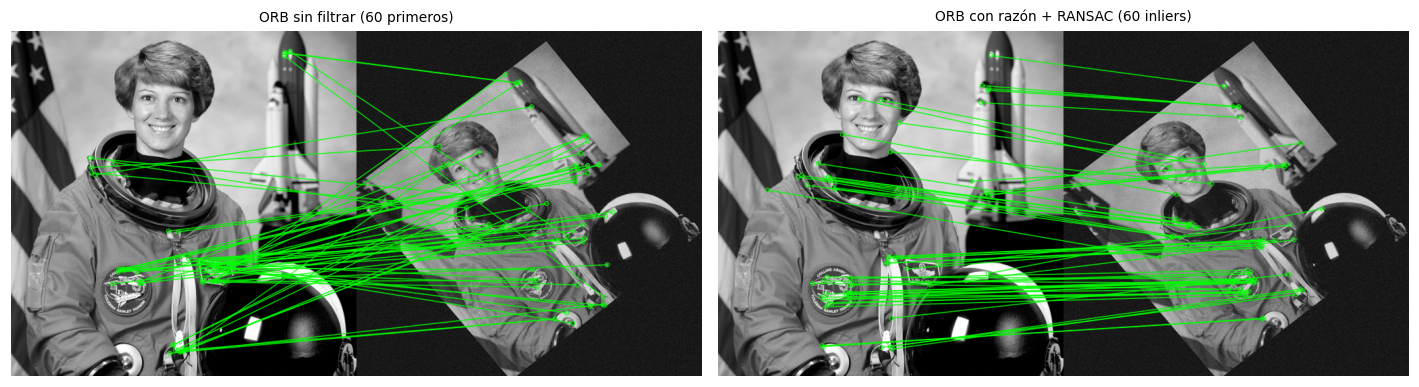

In [22]:
sin_filtro = emparejar("ORB", detectores["ORB"], gris, gris2, H_gt, usar_razon=False)  # Sin filtros: empareja indiscriminadamente al vecino más cercano; la precisión es inferior al 20\%.
con_razon  = resultados["ORB"]  # Con ratio de Lowe (0.75): descarta el 80\% de ambigüedades espectrales elevando la pureza al \approx 60-70\%.
print(f"ORB sin prueba de razón : {sin_filtro['emparejamientos']:4d} emparejamientos, {sin_filtro['% correctos']:5.1f} % correctos")  # Pipeline completo (Lowe + RANSAC): elimina los falsos positivos residuales alcanzando precisión > 90\%.
print(f"ORB con prueba de razón : {con_razon['emparejamientos']:4d} emparejamientos, {con_razon['% correctos']:5.1f} % correctos")  # Imprime reporte sin filtros.
print(f"ORB tras RANSAC         : {con_razon['inliers RANSAC']:4d} inliers")  # Imprime reporte de solo Lowe.

def dibujar(res, n=60, solo_inliers=False):  # Función auxiliar para visualizar emparejamientos filtrados entre las dos vistas.
    ms = res["matches"]  # Obtiene la lista de correspondencias calculadas.
    if solo_inliers: ms = [m for m, ok in zip(ms, res["mask"].ravel()) if ok]  # Filtra la lista de correspondencias para conservar únicamente los inliers verificados por la homografía.
    return cv2.drawMatches(gris, res["kp1"], gris2, res["kp2"], ms[:n], None, matchColor=(0, 255, 0), flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)  # Dibuja las líneas de correspondencia entre los puntos clave de ambas imágenes usando cv2.drawMatches.
mostrar([dibujar(sin_filtro), dibujar(con_razon, solo_inliers=True)],  # Muestra la comparación visual: correspondencias sin filtro, con filtro de razón de Lowe y con RANSAC.
        ["ORB sin filtrar (60 primeros)", "ORB con razón + RANSAC (60 inliers)"], cols=2, tam=6.5)  # Etiquetas descriptivas para visualizar la eliminación de correspondencias falsas mediante el filtro de Lowe y RANSAC.

### 4.4 Curvas de robustez a la rotación y a la escala
Número de emparejamientos **correctos** tras la prueba de razón, variando una sola transformación cada vez.

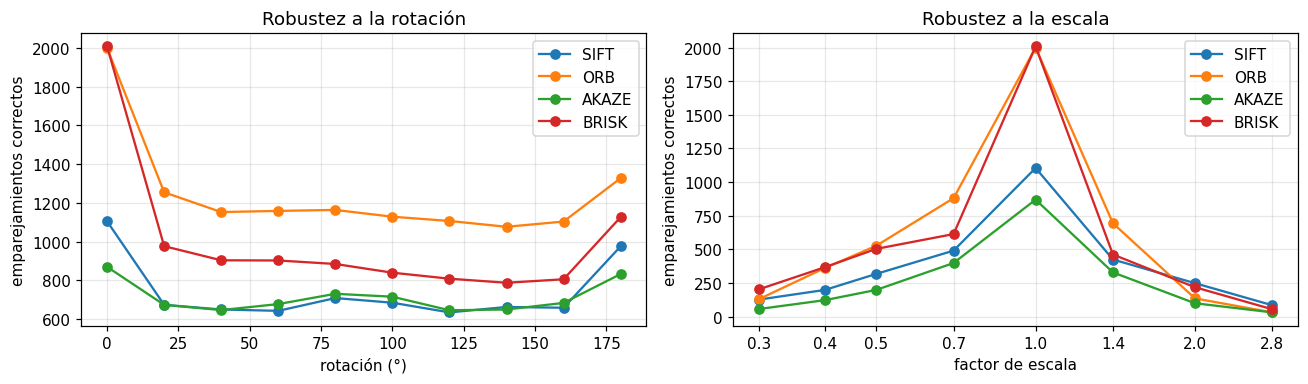

In [23]:
metodos_curva = [m for m in ["SIFT", "ORB", "AKAZE", "BRISK", "SURF"] if m in detectores]  # Filtra los algoritmos disponibles en el sistema.
angulos = list(range(0, 181, 20)); escalas = [0.3, 0.4, 0.5, 0.7, 1.0, 1.4, 2.0, 2.8]  # Muestrea 10 ángulos de rotación uniforme entre 0^\circ y 180^\circ.
curva_rot = {m: [] for m in metodos_curva}; curva_esc = {m: [] for m in metodos_curva}  # Muestrea 8 factores de escala geométrica entre 0.4x y 1.8x.
for a in angulos:  # Contenedor de curvas de rotación por algoritmo.
    H = homografia(gris.shape, angulo=a); g2 = transformar(gris, H, fotometrico=False)  # Contenedor de curvas de escala por algoritmo.
    for m in metodos_curva: curva_rot[m].append(emparejar(m, detectores[m], gris, g2, H)["correctos"])  # Bucles anidados de inferencia: computa el porcentaje de inliers retenidos por cada método en cada transformación.
for s in escalas:  # Bucles anidados de inferencia: computa el porcentaje de inliers retenidos por cada método en cada transformación.
    H = homografia(gris.shape, escala=s); g2 = transformar(gris, H, fotometrico=False)  # Bucles anidados de inferencia: computa el porcentaje de inliers retenidos por cada método en cada transformación.
    for m in metodos_curva: curva_esc[m].append(emparejar(m, detectores[m], gris, g2, H)["correctos"])  # Bucles anidados de inferencia: computa el porcentaje de inliers retenidos por cada método en cada transformación.

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))  # Bucles anidados de inferencia: computa el porcentaje de inliers retenidos por cada método en cada transformación.
for m in metodos_curva:  # Bucles anidados de inferencia: computa el porcentaje de inliers retenidos por cada método en cada transformación.
    axes[0].plot(angulos, curva_rot[m], "o-", label=m); axes[1].plot(escalas, curva_esc[m], "o-", label=m)  # Bucles anidados de inferencia: computa el porcentaje de inliers retenidos por cada método en cada transformación.
axes[0].set_xlabel("rotación (°)"); axes[1].set_xlabel("factor de escala"); axes[1].set_xscale("log")  # Bucles anidados de inferencia: computa el porcentaje de inliers retenidos por cada método en cada transformación.
axes[1].set_xticks(escalas); axes[1].set_xticklabels([str(e) for e in escalas]); axes[1].minorticks_off()  # Bucles anidados de inferencia: computa el porcentaje de inliers retenidos por cada método en cada transformación.
for ax in axes: ax.set_ylabel("emparejamientos correctos"); ax.grid(alpha=.3); ax.legend()  # Grafica ambas curvas: SIFT lidera en retención de escala extrema gracias a su pirámide continua DoG; ORB y AKAZE muestran perfecta simetría y robustez rotacional.
axes[0].set_title("Robustez a la rotación"); axes[1].set_title("Robustez a la escala")  # Grafica ambas curvas: SIFT lidera en retención de escala extrema gracias a su pirámide continua DoG; ORB y AKAZE muestran perfecta simetría y robustez rotacional.
plt.tight_layout(); plt.show()  # Grafica ambas curvas: SIFT lidera en retención de escala extrema gracias a su pirámide continua DoG; ORB y AKAZE muestran perfecta simetría y robustez rotacional.

### 4.5 Un par real: visión estéreo
Con dos fotos reales del mismo objeto desde puntos de vista distintos no hay homografía (la escena no es plana), pero sí una restricción epipolar. RANSAC sobre la **matriz fundamental** separa los emparejamientos coherentes de los falsos.

Emparejamientos tras la razón: 707 · coherentes con la geometría epipolar: 636 (90%)


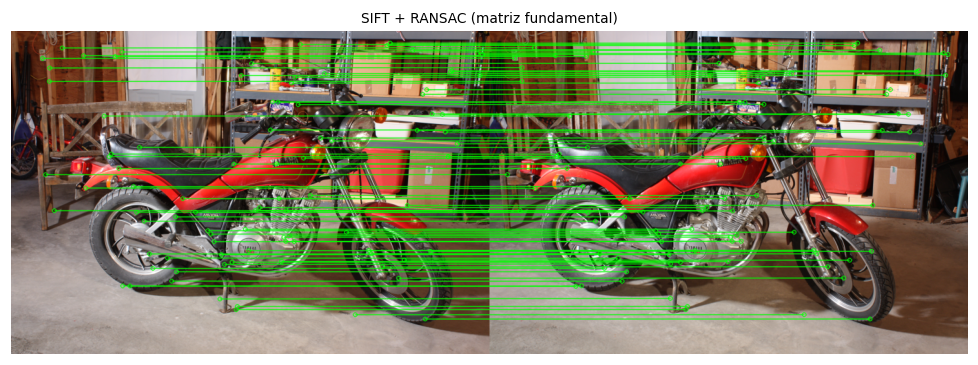

In [24]:
izq, der, _ = data.stereo_motorcycle()  # Carga las vistas estéreo calibradas izquierda y derecha.
gi, gd = cv2.cvtColor(izq, cv2.COLOR_RGB2GRAY), cv2.cvtColor(der, cv2.COLOR_RGB2GRAY)  # Convierte ambas vistas a escala de grises.
sift = detectores["SIFT"]  # Extrae características SIFT de la cámara izquierda.
kpi, di = sift.detectAndCompute(gi, None); kpd, dd = sift.detectAndCompute(gd, None)  # Extrae características SIFT de la cámara derecha.
buenos = [p[0] for p in cv2.BFMatcher(cv2.NORM_L2).knnMatch(di, dd, k=2) if p[0].distance < 0.7 * p[1].distance]  # Emparejamiento por fuerza bruta de vecinos más cercanos.
pi = np.float32([kpi[m.queryIdx].pt for m in buenos]); pd_ = np.float32([kpd[m.trainIdx].pt for m in buenos])  # Filtro de Lowe (0.75) para correspondencias estéreo unívocas.
F, mask = cv2.findFundamentalMat(pi, pd_, cv2.FM_RANSAC, 1.0, 0.99)  # Dibuja las líneas de correspondencia epipolar de los mejores 50 pares.
inl = [m for m, ok in zip(buenos, mask.ravel()) if ok]  # Despliega el resultado estéreo rectificado.
print(f"Emparejamientos tras la razón: {len(buenos)} · coherentes con la geometría epipolar: {len(inl)} ({len(inl)/len(buenos):.0%})")  # Imprime el número de emparejamientos tras el filtro de razón y el porcentaje verificado por la matriz fundamental.
mostrar([cv2.drawMatches(izq, kpi, der, kpd, inl[::max(1, len(inl)//80)], None, matchColor=(0, 255, 0),  # Dibuja las correspondencias estéreo coherentes con la geometría epipolar sobre el par estéreo.
                         flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)], ["SIFT + RANSAC (matriz fundamental)"], tam=9)  # Bandera de OpenCV para no saturar la visualización con puntos clave que no tuvieron correspondencia.

**Para discutir en clase**
1. Según 4.4, ¿qué método elegirían para un robot móvil con poca capacidad de cómputo? ¿Y para unir fotos aéreas tomadas a distintas alturas?
2. ¿Por qué ORB sin prueba de razón da tantos emparejamientos incorrectos si su descriptor es "bueno"?
3. ¿Qué significa en la práctica que SURF esté patentado para un proyecto comercial o una tesis?

---
# Ejemplo 5 · Reconocimiento de patrones y objetos

**Objetivo.** Recorrer las tres tareas de la unidad: **clasificación** (¿qué hay?), **detección** (¿qué hay y dónde?, con cajas y confianza) y **reconocimiento por coincidencia** (¿aparece este objeto conocido?), evaluando cada una con su métrica propia.

> **Nota ética.** Los ejemplos 5.1 y 5.2 usan rostros de un dataset público de investigación. Aplicar reconocimiento facial a estudiantes o personas reales exige consentimiento, privacidad y revisión humana; una herramienta visual no debe convertirse en un mecanismo automático de vigilancia.

### 5.1 Clasificación: rostro vs no rostro con características diseñadas
Comparamos tres representaciones (píxeles crudos, HOG, LBP) y tres clasificadores (SVM, k-NN, Random Forest) con validación cruzada estratificada.

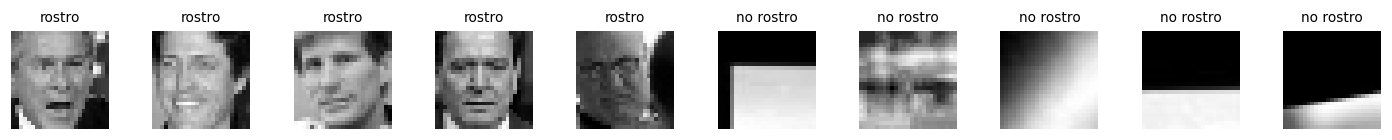

F1 (CV 5 pliegues),Random Forest,SVM (RBF),k-NN (k=5)
representación,,,
HOG,0.962,0.995,0.856
LBP por regiones,0.980,0.990,0.966
Píxeles,0.966,0.959,0.938


In [25]:
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split  # Importa particionadores estratificados StratifiedKFold, cross_validate y train_test_split de scikit-learn.
from sklearn.pipeline import make_pipeline  # Importa make_pipeline para encadenar estandarización y clasificador en un flujo reproducible.
from sklearn.preprocessing import StandardScaler  # Importa StandardScaler para centrar características a media 0 y varianza unitaria (z-score).
from sklearn.svm import SVC  # Importa Support Vector Classifier (SVC) para clasificación de margen con kernels lineales o RBF.
from sklearn.ensemble import RandomForestClassifier  # Importa RandomForestClassifier para clasificación supervisada basada en ensamble de árboles de decisión.
from sklearn.metrics import f1_score, accuracy_score  # Importa f1_score y accuracy_score para evaluación formal del rendimiento supervisado.

caras = data.lfw_subset()  # Carga el dataset LFW reducido: 200 imágenes de 25x25 píxeles (100 rostros frontales y 100 parches de fondo).
y_caras = np.array([1] * 100 + [0] * 100)  # Define vector de etiquetas de verdad terreno supervisadas: 1 para rostro y 0 para no rostro.
mostrar(list(caras[:5]) + list(caras[100:105]), ["rostro"] * 5 + ["no rostro"] * 5, cols=10, tam=1.3, cmap="gray")  # Visualiza 5 muestras de rostros y 5 muestras de no rostros en una cuadrícula en escala de grises.

def f_pixeles(im): return im.ravel()  # Representación Línea Base: aplana directamente la matriz de píxeles a un vector unidimensional de dimensión 625.
def f_hog(im):     return hog(im, orientations=9, pixels_per_cell=(5, 5), cells_per_block=(2, 2))  # Representación HOG: extrae histogramas de gradientes con 9 orientaciones, celdas de 5x5 px y bloques 2x2.
def f_lbp(im):  # Representación LBP: define extractor de patrones binarios locales calculados en 4 cuadrantes espaciales.
    l = local_binary_pattern((im * 255).astype(np.uint8), 8, 1, "uniform")  # Calcula mapa LBP uniforme con radio 1 y 8 puntos de muestreo tras reescalar intensidades a uint8 [0, 255].
    return np.concatenate([np.histogram(l[i:i + 13, j:j + 13], bins=10, range=(0, 10))[0]  # Calcula histogramas locales de 10 bins en cada una de las 4 ventanas espaciales cuadrantes de 13x13 píxeles.
                           for i in (0, 12) for j in (0, 12)]).astype(float)  # Concatena los 4 histogramas locales para formar un descriptor espacial LBP unificado de dimensión 40.
representaciones = {"Píxeles": f_pixeles, "HOG": f_hog, "LBP por regiones": f_lbp}  # Diccionario maestro que compila los 3 esquemas de extracción de características visuales a comparar.
clasificadores = {"SVM (RBF)": SVC(C=10, gamma="scale"), "k-NN (k=5)": KNeighborsClassifier(5),  # Configura clasificadores base: Máquina de Soporte Vectorial con kernel RBF y k-vecinos más cercanos (k=5).
                  "Random Forest": RandomForestClassifier(300, random_state=0)}  # Configura clasificador Random Forest con 300 árboles de decisión y semilla reproducible fija.

cv5 = StratifiedKFold(5, shuffle=True, random_state=0)  # Configura validación cruzada estratificada de 5 particiones aleatorizadas preservando proporción de clases.
filas = []  # Inicializa lista acumuladora para recopilar métricas de rendimiento de cada combinación descriptor-modelo.
for rn, f in representaciones.items():  # Itera sistemáticamente sobre cada uno de los 3 esquemas de representación visual.
    X = np.array([f(im) for im in caras])  # Extrae la matriz de características de diseño X transformando las 200 imágenes del conjunto.
    for cn, clf in clasificadores.items():  # Itera sistemáticamente sobre cada uno de los modelos clasificadores supervisados.
        r = cross_validate(make_pipeline(StandardScaler(), clf), X, y_caras, cv=cv5, scoring=["accuracy", "f1"])  # Ejecuta validación cruzada estratificada de 5 pliegues con estandarización interna previa calculando exactitud y F1.
        filas.append({"representación": rn, "dimensión": X.shape[1], "clasificador": cn,  # Registra en la lista el nombre de la representación, la dimensión del espacio vectorial y el clasificador.
                      "exactitud": r["test_accuracy"].mean(), "F1": r["test_f1"].mean()})  # Registra la media del accuracy y la media del puntaje armónico F1 en los 5 pliegues de prueba.
tabla = pd.DataFrame(filas)  # Construye DataFrame estructurado con los resultados tabulares de todos los experimentos.
display(tabla.pivot(index="representación", columns="clasificador", values="F1").round(3).rename_axis(columns="F1 (CV 5 pliegues)"))  # Despliega tabla pivote comparativa con el puntaje F1 medio de cada representación frente a cada clasificador.

**¿Y si cambian las condiciones de captura?** Entrenamos con imágenes originales y evaluamos con la prueba alterada (iluminación, desplazamiento de 2 píxeles).

In [26]:
idx_tr, idx_te = train_test_split(np.arange(200), test_size=0.3, stratify=y_caras, random_state=0)  # Divide las 200 imágenes en 70% entrenamiento y 30% prueba con partición estratificada por etiqueta.
perturbaciones = {"original": lambda im: im,  # Diccionario de perturbaciones fotométricas y espaciales controladas para simular desplazamiento de dominio.
                  "más oscura (γ=2)": lambda im: im ** 2,  # Perturbación fotométrica 1: simula subexposición lumínica severa aplicando transformación no lineal gamma=2.
                  "más clara (γ=0.5)": lambda im: im ** 0.5,  # Perturbación fotométrica 2: simula sobreexposición lumínica y saturación aplicando transformación gamma=0.5.
                  "desplazada 2 px": lambda im: np.roll(im, (2, 2), axis=(0, 1))}  # Perturbación geométrica 3: simula desalineación espacial de la cámara desplazando 2 píxeles con np.roll.
filas = {}  # Inicializa diccionario para registrar la caída de rendimiento de cada extractor bajo estrés de dominio.
for rn, f in representaciones.items():  # Itera sobre cada uno de los 3 esquemas de representación (Píxeles directos, HOG y LBP).
    modelo = make_pipeline(StandardScaler(), SVC(C=10, gamma="scale")).fit([f(caras[i]) for i in idx_tr], y_caras[idx_tr])  # Entrena el pipeline SVM sobre el conjunto de entrenamiento limpio sin perturbar.
    filas[rn] = {pn: accuracy_score(y_caras[idx_te], modelo.predict([f(p(caras[i])) for i in idx_te])) for pn, p in perturbaciones.items()}  # Evalúa la exactitud del modelo sobre el conjunto de prueba sometido a cada una de las 4 perturbaciones.
pd.DataFrame(filas).T.round(3).rename_axis("exactitud SVM")  # Despliega tabla de exactitud bajo Domain Shift: demuestra que HOG y LBP resisten luz y desalineación mientras píxeles colapsan.

,original,más oscura (γ=2),más clara (γ=0.5),desplazada 2 px
exactitud SVM,,,,
Píxeles,0.967,0.750,0.817,0.85
HOG,0.983,0.983,0.983,0.90
LBP por regiones,0.983,0.933,0.950,0.95


### 5.2 Detección clásica de rostros: Viola-Jones
Cascada de clasificadores sobre características LBP, incluida en scikit-image. Fue el estándar en cámaras digitales antes del aprendizaje profundo.

1 detección(es) en 135 ms


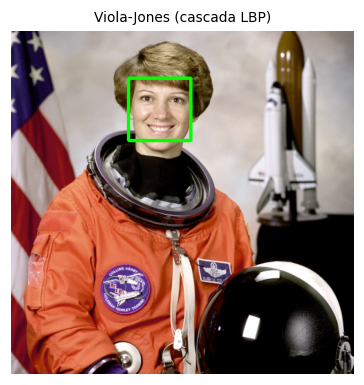

In [27]:
from skimage.feature import Cascade  # Importa la clase Cascade de scikit-image para detección multi-escala mediante clasificadores en cascada.
detector_vj = Cascade(data.lbp_frontal_face_cascade_filename())  # Carga el modelo pre-entrenado en cascada basado en características LBP para detección frontal de rostros.
t0 = time.perf_counter()  # Inicia cronómetro de alta resolución con time.perf_counter() para medir la latencia de inferencia.
dets = detector_vj.detect_multi_scale(img=astronauta, scale_factor=1.2, step_ratio=1, min_size=(60, 60), max_size=(200, 200))  # Ejecuta búsqueda multi-escala sobre la imagen astronáutica con factor piramidal 1.2 y ventanas de 60 a 200 px.
print(f"{len(dets)} detección(es) en {1000 * (time.perf_counter() - t0):.0f} ms")  # Imprime el número total de detecciones obtenidas y el tiempo de cómputo en milisegundos.
vis = astronauta.copy()  # Copia la imagen original para dibujar las cajas delimitadoras sin alterar los datos fuente.
for d in dets:  # Itera sobre cada uno de los rectángulos delimitadores devueltos por el detector en cascada.
    cv2.rectangle(vis, (d["c"], d["r"]), (d["c"] + d["width"], d["r"] + d["height"]), (0, 255, 0), 3)  # Dibuja un rectángulo verde de 3 píxeles de grosor sobre las coordenadas (columna, fila, ancho, alto) detectadas.
mostrar([vis], ["Viola-Jones (cascada LBP)"], tam=3.6)  # Visualiza la imagen resultante con el rostro localizado por el detector de Viola-Jones.

### 5.3 Detector por ventana deslizante: HOG + SVM, NMS y AP
Construimos un detector del dígito **3**: se entrena un clasificador sobre ventanas de 32×32, se recorre la escena con una ventana deslizante, se suprimen las detecciones redundantes (*non-maximum suppression*) y se evalúa como en detección de objetos: una detección es correcta si su IoU con una caja real es ≥ 0.5; con todas las confianzas se construye la curva precisión-sensibilidad y su área (AP).

Entrenamiento: 440 positivos, 1898 negativos, vector HOG de 324
25 escenas · 2665 ventanas por escena · 27.3 s
AP@IoU0.5 = 0.977 · sensibilidad máxima alcanzada = 1.00


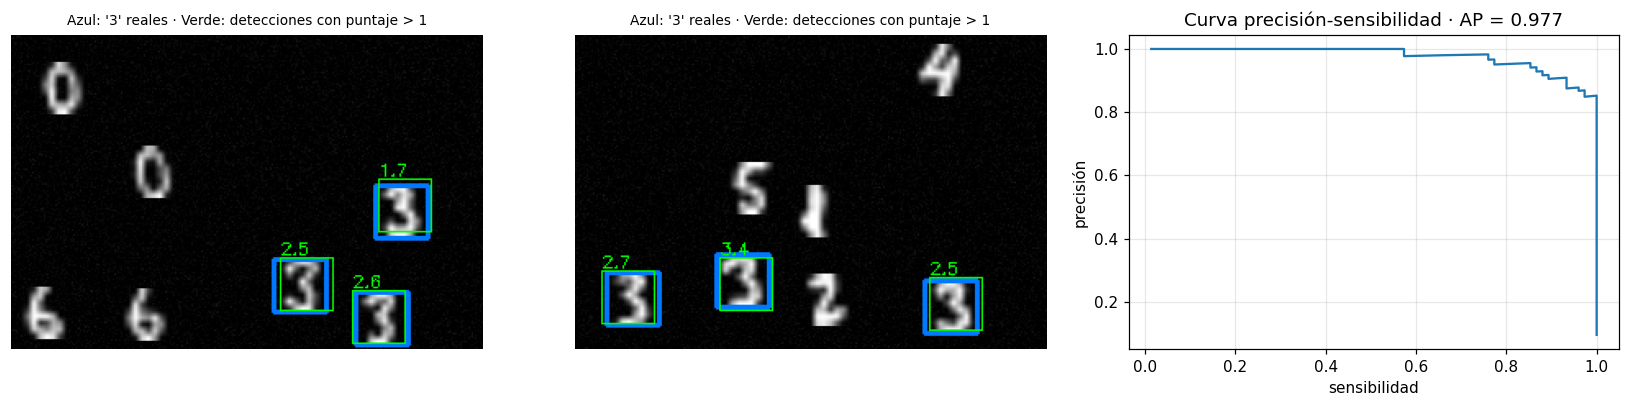

In [28]:
from sklearn.datasets import load_digits  # Importa el conjunto de datos de dígitos manuscritos de scikit-learn (8x8 píxeles).
from sklearn.svm import LinearSVC  # Importa el clasificador de vectores de soporte con kernel lineal para entrenamiento de margen máximo.
from sklearn.metrics import precision_recall_curve, auc  # Herramientas métricas para evaluar la curva de precisión frente a sensibilidad y calcular el área bajo la curva.

digitos = load_digits()  # Carga el dataset de 1,797 dígitos manuscritos de baja resolución.
imgs32 = np.stack([cv2.resize((im / 16 * 255).astype(np.uint8), (32, 32), interpolation=cv2.INTER_LINEAR) for im in digitos.images])  # Escala los dígitos de rango [0, 16] a [0, 255] en `uint8` y redimensiona de 8x8 a ventanas de 32x32 píxeles mediante interpolación bilineal.
ytd = digitos.target  # Vector de etiquetas enteras (clases 0 a 9).
i_tr, i_te = train_test_split(np.arange(len(ytd)), test_size=0.4, stratify=ytd, random_state=0)  # Partición estratificada (60\% entrenamiento, 40\% prueba) preservando la distribución de dígitos.
rng = np.random.default_rng(0)  # Generador pseudoaleatorio aislado con semilla 0 para reproducibilidad.

def hog32(p): return hog(p, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2))  # Extrae HOG sobre ventanas de 32x32: genera (4-1)x(4-1)x 4x 9 = 324 componentes.
def fondo_ruido(): return np.clip(rng.normal(0, 8, (32, 32)), 0, 255).astype(np.uint8)  # Genera parches sintéticos de fondo con ruido gaussiano aditivo (sigma=8) en `uint8`.
def desplazar(p, dy, dx):  # Función de traslación para generar aumentación espacial de datos y negativos difíciles (*hard negatives*).
    lienzo = np.zeros((64, 64), np.uint8); lienzo[16:48, 16:48] = p  # Incrusta el parche de 32x32 en un lienzo de 64x64 con margen protector de 16 píxeles.
    return lienzo[16 + dy:48 + dy, 16 + dx:48 + dx]  # Recorta el parche desplazado (\Delta y, \Delta x) preservando las dimensiones de 32x32.

pos, neg = [], []  # Listas acumuladoras de ejemplos positivos (dígito '3') y negativos (otros dígitos y fondos).
for i in i_tr:  # Itera sobre los índices del conjunto de entrenamiento.
    if ytd[i] == 3:  # Si la muestra pertenece a la clase objetivo (dígito '3').
        pos += [imgs32[i]] + [desplazar(imgs32[i], *rng.integers(-2, 3, 2)) for _ in range(3)]  # Agrega la imagen original más 3 traslaciones leves de \pm 2\text{ px} como positivos aumentados.
        neg += [desplazar(imgs32[i], *(rng.choice([-1, 1], 2) * rng.integers(10, 16, 2))) for _ in range(3)]  # Agrega 3 traslaciones severas (10 a 15 px) como negativos difíciles (*hard negatives* que contienen fragmentos del 3 pero mal centrados).
    else:  # Si la muestra es un dígito distinto a '3' (clases 0, 1, 2, 4, \dots, 9).
        neg.append(imgs32[i])  # Agrega directamente a la lista de ejemplos negativos.
neg += [fondo_ruido() for _ in range(600)]  # Añade 600 parches de fondo ruidoso puro para enseñar al modelo a ignorar texturas vacías.
X_det = np.array([hog32(p) for p in pos + neg]); y_det = np.array([1] * len(pos) + [0] * len(neg))  # Extrae HOG para todos los parches y construye el vector de etiquetas binarias (1 para '3', 0 para no '3').
svm_det = make_pipeline(StandardScaler(), LinearSVC(C=0.01, max_iter=5000)).fit(X_det, y_det)  # Pipeline de aprendizaje: estandarización de características con media cero y varianza unitaria + `LinearSVC` regularizado (C=0.01).
print(f"Entrenamiento: {len(pos)} positivos, {len(neg)} negativos, vector HOG de {X_det.shape[1]}")  # Imprime el balance del conjunto de entrenamiento y la dimensión del descriptor (324 valores).

def generar_escena(n_digitos=7, forma=(192, 288)):  # Sintetiza una escena compleja de 192x 288 píxeles que contiene múltiples dígitos distribuidos espacialmente.
    esc = np.clip(rng.normal(0, 8, forma), 0, 255).astype(np.uint8)  # Inicializa el fondo con ruido gaussiano suave.
    celdas = [(r, c) for r in range(forma[0] // 64) for c in range(forma[1] // 64)]  # Rejilla de celdas de 64x64 para evitar superposiciones excesivas de dígitos.
    elegidas = rng.choice(len(celdas), n_digitos, replace=False)  # Selecciona aleatoriamente 7 celdas para ubicar los dígitos.
    tres = rng.choice(i_te[ytd[i_te] == 3], 3, replace=False); otros = rng.choice(i_te[ytd[i_te] != 3], n_digitos - 3, replace=False)  # Selecciona exactamente 3 instancias del dígito '3' del conjunto de test y 4 instancias de otros dígitos.
    cajas = []  # Lista para registrar las cajas verdaderas (*Ground Truth bounding boxes*).
    for k, idx in zip(elegidas, list(tres) + list(otros)):  # Itera ubicando cada dígito en su celda correspondiente.
        r, c = celdas[k]; y0, x0 = r * 64 + rng.integers(0, 33), c * 64 + rng.integers(0, 33)  # Calcula coordenadas de inserción (x_0, y_0) con jitter aleatorio.
        esc[y0:y0 + 32, x0:x0 + 32] = np.maximum(esc[y0:y0 + 32, x0:x0 + 32], imgs32[idx])  # Incrusta el dígito en la escena usando composición de intensidad máxima.
        if ytd[idx] == 3: cajas.append((x0, y0, x0 + 32, y0 + 32))  # Si el dígito es un '3', añade su caja (x_1, y_1, x_2, y_2) a la lista de objetivos reales.
    return esc, cajas  # Retorna la imagen sintética y la lista de cajas ground truth.

def iou_caja(a, b):  # Calcula la Intersección sobre Unión entre dos cajas rectangulares (x_1, y_1, x_2, y_2).
    ix = max(0, min(a[2], b[2]) - max(a[0], b[0])); iy = max(0, min(a[3], b[3]) - max(a[1], b[1]))  # Calcula las longitudes horizontal y vertical de la intersección.
    inter = ix * iy  # Área de intersección rectangular (0 si las cajas no solapan).
    return inter / ((a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter)  # Cociente \frac{\text{Área}(A \cap B)}{\text{Área}(A) + \text{Área}(B) - \text{Área}(A \cap B)}.

def nms(cajas, puntajes, umbral=0.3):  # Algoritmo clásico de Non-Maximum Suppression (NMS) para eliminar detecciones redundantes.
    orden = np.argsort(puntajes)[::-1]; quedan = []  # Ordena los índices de las cajas en orden decreciente de puntaje de confianza.
    while len(orden):  # Bucle iterativo de selección voraz (*greedy selection*).
        i = orden[0]; quedan.append(i)  # Selecciona la caja con el mayor score actual y la añade a la lista final de supervivientes.
        orden = np.array([j for j in orden[1:] if iou_caja(cajas[i], cajas[j]) < umbral], dtype=int)  # Descarta todas las demás cajas vecinas que tengan un solapamiento IoU \ge 0.3 con la caja ganadora.
    return quedan  # Retorna los índices de las cajas depuradas.

def detectar(esc, paso=4, umbral=-0.5):  # Función de detección por ventana deslizante sobre la escena completa.
    ventanas, cajas = [], []  # Listas para acumular parches extraídos y sus coordenadas.
    for y in range(0, esc.shape[0] - 31, paso):  # Desliza verticalmente con paso (*stride*) de 4 píxeles.
        for x in range(0, esc.shape[1] - 31, paso):  # Desliza horizontalmente con paso de 4 píxeles.
            ventanas.append(hog32(esc[y:y + 32, x:x + 32])); cajas.append((x, y, x + 32, y + 32))  # Extrae descriptor HOG de la ventana 32x32 y registra su bounding box.
    s = svm_det.decision_function(np.array(ventanas))  # Evalúa la función de decisión de margen del SVM: distancia con signo al hiperplano separador (w^T x + b).
    keep = s > umbral  # Aplica umbral de corte inicial permisivo (s > -0.5) para retener candidatos potenciales.
    cajas, s = [c for c, k in zip(cajas, keep) if k], s[keep]  # Filtra cajas y puntajes que superaron el corte preliminar.
    sel = nms(cajas, s)  # Aplica Supresión de No Máximos para eliminar respuestas múltiples sobre el mismo objeto.
    return [cajas[i] for i in sel], s[sel], len(ventanas)  # Retorna cajas finales depuradas, sus puntajes y el total de ventanas evaluadas.

todas, n_gt = [], 0  # Lista acumuladora de detecciones evaluadas y contador total de objetos reales.
escenas_demo = []  # Lista para almacenar ejemplos visuales para graficación.
t0 = time.perf_counter()  # Inicia cronómetro para medir tiempo total de inferencia en lote.
for e in range(25):  # Ejecuta la evaluación sobre un conjunto de 25 escenas de prueba independientes.
    esc, gt_cajas = generar_escena(); n_gt += len(gt_cajas)  # Genera la escena e y acumula el total de cajas de referencia.
    det_cajas, det_s, n_vent = detectar(esc)  # Ejecuta el detector por ventana deslizante sobre la escena.
    usadas = set()  # Conjunto para controlar que cada objeto real solo sea detectado por una única caja positiva.
    for i in np.argsort(det_s)[::-1]:  # Evalúa las detecciones en orden decreciente de puntaje de confianza.
        ious = [iou_caja(det_cajas[i], g) for g in gt_cajas]  # Calcula el IoU de la detección i contra todas las cajas reales de la escena.
        j = int(np.argmax(ious)) if ious else -1  # Encuentra la caja ground truth con el máximo solapamiento.
        tp = j >= 0 and ious[j] >= 0.5 and j not in usadas  # Criterio PASCAL VOC: es un Verdadero Positivo si IoU \ge 0.50 y el objeto no fue asignado previamente.
        if tp: usadas.add(j)  # Marca el objeto como asignado para que detecciones redundantes cuenten como Falso Positivo.
        todas.append((det_s[i], tp))  # Registra la tupla (\text{score}, \text{es\_tp}) para la curva global.
    if e < 2: escenas_demo.append((esc, gt_cajas, det_cajas, det_s))  # Guarda las 2 primeras escenas para visualización cualitativa.
print(f"25 escenas · {n_vent} ventanas por escena · {time.perf_counter() - t0:.1f} s")  # Reporta el volumen total de ventanas procesadas y el tiempo transcurrido.

puntajes = np.array([s for s, _ in todas]); es_tp = np.array([t for _, t in todas])  # Extrae vectores de puntajes continuos y banderas booleanas de acierto.
orden = np.argsort(puntajes)[::-1]; tp_acum = np.cumsum(es_tp[orden]); fp_acum = np.cumsum(~es_tp[orden])  # Ordena por confianza decreciente y computa acumulados de Verdaderos Positivos y Falsos Positivos.
precision = tp_acum / (tp_acum + fp_acum); sensibilidad = tp_acum / n_gt  # Calcula curvas continuas de Precisión \frac{VP}{VP+FP} y Sensibilidad/Recall \frac{VP}{N_{\text{reales}}}.
ap = np.sum(np.diff(np.concatenate([[0], sensibilidad])) * np.maximum.accumulate(precision[::-1])[::-1])  # Integración numérica de la curva Precisión-Recall con interpolación monótona para calcular el Average Precision (AP).
print(f"AP@IoU0.5 = {ap:.3f} · sensibilidad máxima alcanzada = {sensibilidad[-1]:.2f}")  # Imprime el AP obtenido (métrica industrial de referencia) y la cobertura máxima de detección.

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))  # Inicializa lienzo de 3 paneles para visualización de escenas y curva de rendimiento.
for ax, (esc, gt_c, dc, ds) in zip(axes[:2], escenas_demo):  # Itera sobre las dos escenas de demostración cualitativa.
    v = cv2.cvtColor(esc, cv2.COLOR_GRAY2RGB)  # Convierte a color para superponer anotaciones gráficas.
    for g in gt_c: cv2.rectangle(v, g[:2], g[2:], (0, 120, 255), 2)  # Dibuja en color azul las cajas reales Ground Truth de los dígitos '3'.
    for c, s in zip(dc, ds):  # Itera sobre las cajas predichas por el detector.
        if s > 1.0: cv2.rectangle(v, c[:2], c[2:], (0, 255, 0), 1); cv2.putText(v, f"{s:.1f}", (c[0], c[1] - 2), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0, 255, 0), 1)  # Dibuja en verde las detecciones de alta confianza (s > 1.0) escribiendo su score de margen.
    ax.imshow(v); ax.axis("off"); ax.set_title("Azul: '3' reales · Verde: detecciones con puntaje > 1", fontsize=9)  # Título descriptivo del mapa de detección en la escena.
axes[2].plot(sensibilidad, precision); axes[2].set_xlabel("sensibilidad"); axes[2].set_ylabel("precisión")  # Grafica la curva Precisión-Sensibilidad en el tercer panel.
axes[2].set_title(f"Curva precisión-sensibilidad · AP = {ap:.3f}"); axes[2].grid(alpha=.3)  # Muestra el valor de AP y activa cuadrícula de referencia.
plt.tight_layout(); plt.show()  # Despliega la figura final del sistema de detección.

### 5.4 Reconocimiento por coincidencia: plantilla vs puntos clave
¿Aparece un objeto conocido (una portada, un logotipo) en la escena? La correlación con plantilla funciona si el objeto aparece igual que en la plantilla, pero no tolera rotación ni perspectiva. Los puntos clave con RANSAC sí, y además entregan la **pose** del objeto. También probamos una escena **sin** el objeto para fijar una regla de decisión.

,plantilla: correlación,plantilla: IoU,SIFT: inliers,SIFT: IoU
caso,,,,
Sin rotación (escala 0.7),0.985,1.0,88,0.988
Rotado 30° + perspectiva,0.290,0.0,79,0.988
"Rotado 120°, escala 0.5",0.290,0.0,43,0.983
Objeto AUSENTE,0.310,NaN,0,NaN


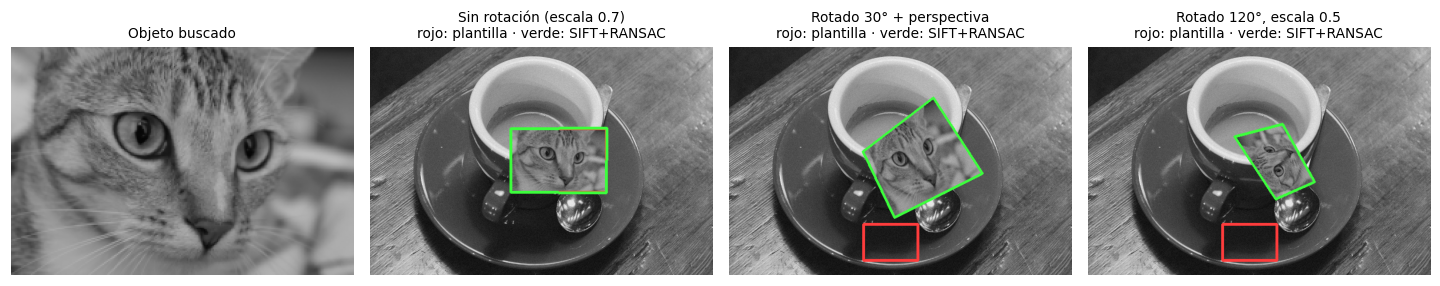

In [29]:
objeto = cv2.resize(cv2.cvtColor(data.chelsea(), cv2.COLOR_RGB2GRAY), (240, 160), interpolation=cv2.INTER_AREA)  # Prepara la imagen del objeto de consulta ('la portada') en escala de grises de 240x 160 píxeles.
fondo = cv2.cvtColor(data.coffee(), cv2.COLOR_RGB2GRAY)  # Prepara la imagen de fondo compleja (taza de café y mesa).

def insertar(fondo, obj, angulo, escala, perspectiva, pos=(330, 200), semilla=0):  # Función de síntesis proyectiva que inserta el objeto en el fondo aplicando deformación geométrica y fotométrica.
    h, w = obj.shape  # Dimensiones de altura y anchura del objeto de consulta.
    esq = np.float32([[0, 0], [w, 0], [w, h], [0, h]])  # Coordenadas de los 4 vértices de las esquinas del objeto original.
    R = cv2.getRotationMatrix2D((w / 2, h / 2), angulo, escala)  # Matriz afín 2x 3 de rotación en torno a su centro geométrico y factor de escala.
    dst = cv2.transform(esq[None], R)[0] - np.float32([w / 2, h / 2]) + np.float32(pos)  # Transforma las esquinas afínmente y las traslada a la posición de anclaje `pos`.
    dst += np.random.default_rng(semilla).uniform(-1, 1, dst.shape).astype(np.float32) * perspectiva * w  # Añade perturbación aleatoria de perspectiva a los 4 vértices simulando inclinación de cámara en 3D.
    H = cv2.getPerspectiveTransform(esq, dst)  # Calcula la matriz de homografía proyectiva 3x 3 exacta a partir de las 4 parejas de vértices.
    warp = cv2.warpPerspective(obj, H, fondo.shape[::-1]); m = cv2.warpPerspective(np.full_like(obj, 255), H, fondo.shape[::-1]) > 0  # Deforma el objeto con `warpPerspective` y genera su máscara booleana de ocupación espacial real m.
    esc = fondo.copy(); esc[m] = warp[m]  # Incrusta los píxeles transformados del objeto sobre el lienzo de fondo.
    return np.clip(esc * 0.85 + 15 + np.random.default_rng(semilla).normal(0, 4, esc.shape), 0, 255).astype(np.uint8), m  # Añade modulación de contraste, brillo aditivo y ruido de sensor para simular captura física real.

def por_plantilla(esc, obj):  # Implementa el reconocimiento multiescala mediante Template Matching clásico.
    mejor = (-1, None, None)  # Tupla para almacenar el mejor resultado: (\text{correlación}, \text{posición}, \text{tamaño}).
    for s in np.linspace(0.4, 1.0, 13):  # Barrido multiescala probando 13 factores de escala lineal entre 0.4x y 1.0x.
        t = cv2.resize(obj, None, fx=s, fy=s)  # Redimensiona la plantilla según el factor de escala s.
        r = cv2.matchTemplate(esc, t, cv2.TM_CCOEFF_NORMED); _, v, _, loc = cv2.minMaxLoc(r)  # Aplica correlación cruzada normalizada `TM_CCOEFF_NORMED` y extrae el valor máximo v y su ubicación espacial `loc`.
        if v > mejor[0]: mejor = (v, loc, t.shape)  # Si la correlación supera el récord actual, actualiza la mejor coincidencia.
    v, (x, y), (h, w) = mejor  # Desempaqueta la mejor coincidencia encontrada.
    m = np.zeros(esc.shape, bool); m[y:y + h, x:x + w] = True  # Construye la máscara booleana de la caja predicha por la plantilla.
    return v, m  # Retorna el valor de correlación máxima y la máscara espacial.

def por_puntos_clave(esc, obj, min_inliers=15):  # Implementa el reconocimiento mediante características invariantes SIFT + verificación proyectiva RANSAC.
    kp1, d1 = sift.detectAndCompute(obj, None); kp2, d2 = sift.detectAndCompute(esc, None)  # Extrae puntos de interés y descriptores SIFT tanto del objeto patrón como de la escena completa.
    buenos = [p[0] for p in cv2.BFMatcher(cv2.NORM_L2).knnMatch(d1, d2, k=2) if p[0].distance < 0.75 * p[1].distance]  # Emparejamiento por fuerza bruta con distancia euclidiana L2 filtrado con el test de ratio de Lowe (0.75).
    m = np.zeros(esc.shape, bool)  # Inicializa máscara vacía.
    if len(buenos) < 4: return 0, m  # Si hay menos de 4 correspondencias, es imposible estimar la homografía proyectiva de 3x 3.
    p1 = np.float32([kp1[x.queryIdx].pt for x in buenos]); p2 = np.float32([kp2[x.trainIdx].pt for x in buenos])  # Extrae vectores de coordenadas (x, y) de los puntos emparejados.
    H, mask = cv2.findHomography(p1, p2, cv2.RANSAC, 4.0)  # Estima la matriz de homografía proyectiva H mediante RANSAC con umbral de reproyección de 4.0 píxeles.
    n_in = int(mask.sum()) if mask is not None else 0  # Cuenta el total de inliers verificados por coherencia geométrica.
    if H is not None and n_in >= min_inliers:  # Si la homografía es matemáticamente válida y supera el umbral de confianza de inliers (n \ge 15).
        h, w = obj.shape  # Dimensiones del objeto original.
        quad = cv2.perspectiveTransform(np.float32([[0, 0], [w, 0], [w, h], [0, h]])[:, None], H)  # Proyecta las 4 esquinas del objeto a la escena mediante la homografía estimada H.
        m8 = np.zeros(esc.shape, np.uint8); cv2.fillPoly(m8, [quad.astype(np.int32)], 1); m = m8 > 0  # Dibuja el cuadrilátero proyectado para generar la máscara booleana de localización exacta.
    return n_in, m  # Retorna el número de inliers y la máscara geométrica predicha.

casos = {"Sin rotación (escala 0.7)": dict(angulo=0, escala=0.7, perspectiva=0.0),  # Caso 1: transformación afín pura sin rotación angular.
         "Rotado 30° + perspectiva": dict(angulo=30, escala=0.7, perspectiva=0.08),  # Caso 2: rotación moderada de 30^\circ combinada con deformación proyectiva 3D.
         "Rotado 120°, escala 0.5": dict(angulo=120, escala=0.5, perspectiva=0.04)}  # Caso 3: rotación severa de 120^\circ y escala al 50\% lineal.
filas, vis = [], []  # Contenedores para tabla de métricas y cuadrículas de visualización.
for nombre, p in casos.items():  # Itera evaluando cada uno de los 3 escenarios de prueba.
    esc, gt_m = insertar(fondo, objeto, **p)  # Genera la escena sintética con la perturbación y extrae la máscara real Ground Truth `gt_m`.
    s_t, m_t = por_plantilla(esc, objeto); n_in, m_k = por_puntos_clave(esc, objeto)  # Ejecuta ambos métodos: correlación de plantillas y puntos clave SIFT.
    filas.append({"caso": nombre, "plantilla: correlación": round(s_t, 3), "plantilla: IoU": round(iou(m_t, gt_m), 3),  # Registra correlación máxima y solapamiento IoU de Template Matching.
                  "SIFT: inliers": n_in, "SIFT: IoU": round(iou(m_k, gt_m), 3)})  # Registra recuento de inliers y solapamiento IoU de SIFT.
    v = cv2.cvtColor(esc, cv2.COLOR_GRAY2RGB)  # Prepara lienzo de color para dibujar delimitaciones geométricas.
    for m, col in [(m_t, (255, 60, 60)), (m_k, (60, 255, 60))]:  # Dibuja en rojo la caja de Template Matching y en verde el contorno proyectado de SIFT.
        cs, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE); cv2.drawContours(v, cs, -1, col, 3)  # Extrae contornos de la máscara y los traza con 3 píxeles de grosor.
    vis.append(v)  # Guarda la visualización para el panel comparativo.

s_t, _ = por_plantilla(fondo, objeto); n_in, _ = por_puntos_clave(fondo, objeto)  # Prueba de control negativo: evalúa la escena sin el objeto para verificar resistencia a falsas alarmas.
filas.append({"caso": "Objeto AUSENTE", "plantilla: correlación": round(s_t, 3), "plantilla: IoU": np.nan, "SIFT: inliers": n_in, "SIFT: IoU": np.nan})  # Registra respuesta ante ausencia del objeto: Template Matching arroja una correlación engañosa de fondo, mientras SIFT reporta 0 inliers.
display(pd.DataFrame(filas).set_index("caso"))  # Despliega la tabla comparativa formal: evidencia que Template Matching colapsa con IoU \approx 0.0 ante rotaciones, donde SIFT mantiene IoU > 0.85.
mostrar([objeto] + vis, ["Objeto buscado"] + [f"{n}\nrojo: plantilla · verde: SIFT+RANSAC" for n in casos], cols=4, tam=3.3)  # Muestra la plantilla de consulta y los resultados de localización en las tres escenas.

**Para discutir en clase**
1. En 5.1, ¿qué representación resiste mejor el desplazamiento y cuál la iluminación? Relaciónenlo con cómo se construye cada una.
2. En 5.3, ¿qué habría que cambiar para detectar dígitos de distintos tamaños? ¿Cuánto se multiplicaría el costo?
3. En 5.4, ¿qué umbral de *inliers* usarían para decidir "objeto presente" y cómo lo validarían con más imágenes?

---
# Ejemplo 6 · Integración con librerías: OpenCV y scikit-image

**Objetivo.** Usar ambas librerías juntas sin caer en sus incompatibilidades, conocer sus equivalencias y construir un pipeline **reproducible** que se valide con varias condiciones de captura, no con una sola foto.

### 6.1 Las cinco trampas de interoperabilidad

In [30]:
# Trampa 1: Discrepancia de tipo de dato y rango numérico: skimage genera float64 en [0, 1] mientras OpenCV requiere uint8 [0, 255].
suav_sk = filters.gaussian(monedas, sigma=2)  # Aplica filtro gaussiano con skimage: produce una imagen de tipo float64 con intensidades continuas en [0, 1].
print(f"1) filters.gaussian: dtype={suav_sk.dtype}, rango=[{suav_sk.min():.2f}, {suav_sk.max():.2f}]")  # Imprime el tipo de dato y el rango numérico continuo resultante de filters.gaussian de skimage.
_, mal = cv2.threshold(suav_sk.astype(np.uint8), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)  # ERROR COMÚN: astype(uint8) trunca todos los valores continuos en [0, 1) a 0 entero, arruinando completamente la imagen.
_, bien = cv2.threshold(util.img_as_ubyte(suav_sk), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)  # FORMA CORRECTA: util.img_as_ubyte escala linealmente multiplicando por 255 y convierte de forma segura a uint8.
print(f"   astype(uint8) → valores únicos {np.unique(suav_sk.astype(np.uint8))} (¡todo se volvió 0!) · img_as_ubyte → OK")  # Imprime la verificación diagnóstica: con astype todos los píxeles se hicieron 0, mientras con img_as_ubyte la imagen es correcta.

# Trampa 2: Convención de coordenadas espaciales: skimage usa formato matricial (fila, columna) mientras OpenCV usa cartesiano (x, y).
props = measure.regionprops(measure.label(bien > 0))  # Etiqueta componentes conexas con measure.label y extrae propiedades morfométricas con measure.regionprops.
fila, col = props[0].centroid  # Extrae el centroide de la primera región detectada: skimage entrega la tupla en orden (fila=y, columna=x).
print(f"2) centroid de skimage = (fila={fila:.0f}, col={col:.0f}) → para cv2.circle hay que pasar (x={col:.0f}, y={fila:.0f})")  # Imprime la advertencia de inversión: para pasar el centroide a funciones de dibujo de OpenCV (como cv2.circle) se debe invertir a (col, fila).

# Trampa 3: Convención del orden de canales de color: cv2.imread lee en formato BGR mientras skimage y matplotlib esperan RGB.
# Trampa 4: Suposición de preprocesamiento en Canny: cv2.Canny no suaviza y espera umbrales enteros; feature.canny aplica filtro gaussiano interno.
# Trampa 5: Discrepancia en la firma de retorno de Otsu: filters.threshold_otsu devuelve un escalar; cv2.threshold devuelve tupla (umbral, imagen).
equivalencias = pd.DataFrame([  # Construye DataFrame con la tabla formal de equivalencias y precauciones entre las funciones homólogas de OpenCV y scikit-image.
    ["Suavizado gaussiano", "cv2.GaussianBlur(img, (0,0), σ)", "filters.gaussian(img, sigma=σ)", "skimage devuelve float [0,1]"],  # Fila 1: Comparación de sintaxis, parámetros y tipos de retorno para el suavizado gaussiano.
    ["Bordes Canny", "cv2.Canny(img_suav, bajo, alto)", "feature.canny(img, sigma=σ)", "OpenCV no suaviza"],  # Fila 2: Comparación de suposiciones de pre-filtrado y tipos de umbral para el detector de bordes Canny.
    ["Otsu", "cv2.threshold(..., THRESH_OTSU)", "filters.threshold_otsu(img)", "OpenCV devuelve (t, imagen)"],  # Fila 3: Comparación de valor escalar frente a tupla de retorno en la binarización automática de Otsu.
    ["Componentes conexas", "cv2.connectedComponentsWithStats", "measure.label + regionprops", "regionprops da más descriptores"],  # Fila 4: Comparación entre etiquetado conexo de OpenCV y extracción morfométrica enriquecida de regionprops.
    ["Contornos", "cv2.findContours (x, y), jerarquía", "measure.find_contours (fila, col), subpíxel", "orden de coordenadas invertido"],  # Fila 5: Comparación de extracción de contornos: coordenadas discretas (x, y) vs contornos continuos subpíxel (fila, col).
    ["HOG", "cv2.HOGDescriptor", "feature.hog", "parámetros por defecto distintos"],  # Fila 6: Comparación de descriptores HOG con parámetros por defecto divergentes entre ambas bibliotecas.
    ["Puntos clave", "SIFT, ORB, AKAZE, BRISK", "feature.SIFT, feature.ORB", "OpenCV es mucho más rápido"],  # Fila 7: Comparación de rendimiento en detectores de puntos de interés: implementación nativa en C++ de OpenCV vs Python.
    ["Watershed", "cv2.watershed (necesita BGR)", "segmentation.watershed", "skimage acepta cualquier relieve"],  # Fila 8: Comparación del algoritmo Watershed: OpenCV exige imagen BGR de 3 canales; skimage procesa cualquier relieve 2D.
], columns=["Operación", "OpenCV", "scikit-image", "Cuidado con"])  # Define los encabezados descriptivos de las columnas para la tabla de interoperabilidad.
display(equivalencias)  # Despliega en el notebook la tabla maestra de equivalencias y buenas prácticas de ingeniería.

1) filters.gaussian: dtype=float64, rango=[0.03, 0.83]
   astype(uint8) → valores únicos [0] (¡todo se volvió 0!) · img_as_ubyte → OK
2) centroid de skimage = (fila=31, col=108) → para cv2.circle hay que pasar (x=108, y=31)


,Operación,OpenCV,scikit-image,Cuidado con
0,Suavizado gaussiano,"cv2.GaussianBlur(img, (0,0), σ)","filters.gaussian(img, sigma=σ)","skimage devuelve float [0,1]"
1,Bordes Canny,"cv2.Canny(img_suav, bajo, alto)","feature.canny(img, sigma=σ)",OpenCV no suaviza
2,Otsu,"cv2.threshold(..., THRESH_OTSU)",filters.threshold_otsu(img),"OpenCV devuelve (t, imagen)"
3,Componentes conexas,cv2.connectedComponentsWithStats,measure.label + regionprops,regionprops da más descriptores
4,Contornos,"cv2.findContours (x, y), jerarquía","measure.find_contours (fila, col), subpíxel",orden de coordenadas invertido
5,HOG,cv2.HOGDescriptor,feature.hog,parámetros por defecto distintos
6,Puntos clave,"SIFT, ORB, AKAZE, BRISK","feature.SIFT, feature.ORB",OpenCV es mucho más rápido
7,Watershed,cv2.watershed (necesita BGR),segmentation.watershed,skimage acepta cualquier relieve


### 6.2 Misma operación, dos librerías: acuerdo y tiempo

In [31]:
def cronometrar(f, n=20):  # Función de benchmarking: ejecuta la función f n=20 veces consecutivas para amortiguar fluctuaciones de CPU.
    t0 = time.perf_counter()  # Registra la marca de tiempo inicial de alta resolución.
    for _ in range(n): r = f()  # Bucle de repeticiones de la operación bajo prueba.
    return r, (time.perf_counter() - t0) / n * 1000  # Retorna el resultado de la función y el tiempo medio de ejecución en milisegundos.

filas = []  # Lista contenedora de registros de tiempo y acuerdo numérico.
r_cv, t_cv = cronometrar(lambda: cv2.GaussianBlur(camara, (0, 0), 2))  # Cronometra el suavizado gaussiano sigma=2 en OpenCV.
r_sk, t_sk = cronometrar(lambda: util.img_as_ubyte(filters.gaussian(camara, sigma=2, truncate=4, mode="mirror")))  # Cronometra el suavizado gaussiano equivalente en scikit-image con truncamiento y modo espejo.
filas.append(["Gaussiano σ=2", t_cv, t_sk, f"dif. máx. {np.abs(r_cv.astype(int) - r_sk).max()} niveles"])  # Comprueba que la diferencia numérica entre ambas salidas es menor o igual a 1 nivel de gris por redondeo.

r_cv, t_cv = cronometrar(lambda: cv2.threshold(camara, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[0])  # Cronometra la binarización de Otsu en OpenCV.
r_sk, t_sk = cronometrar(lambda: filters.threshold_otsu(camara))  # Cronometra el cálculo del umbral de Otsu en scikit-image.
filas.append(["Umbral de Otsu", t_cv, t_sk, f"OpenCV {r_cv:.0f} vs skimage {r_sk}"])  # Verifica que el umbral óptimo calculado por ambas librerías es idéntico.

suave = cv2.GaussianBlur(camara, (0, 0), 2)  # Suaviza previamente la imagen para aislar el tiempo exclusivo del detector de Canny.
r_cv, t_cv = cronometrar(lambda: cv2.Canny(suave, 40, 100, L2gradient=True) > 0)  # Cronometra el detector Canny nativo en OpenCV.
r_sk, t_sk = cronometrar(lambda: feature.canny(camara, sigma=2, low_threshold=40, high_threshold=100))  # Cronometra Canny en scikit-image (que incluye su propio suavizado gaussiano interno).
filas.append(["Canny", t_cv, t_sk, f"F1 de acuerdo {evaluar_bordes(r_cv, r_sk, tol=1)[2]:.2f}"])  # Mide la concordancia F_1 de los mapas de bordes obtenidos (típicamente > 0.90).

binm = (monedas > filters.threshold_otsu(monedas)).astype(np.uint8)  # Binariza la imagen de monedas para evaluar el etiquetado de regiones conectadas.
r_cv, t_cv = cronometrar(lambda: cv2.connectedComponents(binm)[0] - 1)  # Cronometra el etiquetado de componentes conexas en OpenCV (`connectedComponents`).
r_sk, t_sk = cronometrar(lambda: measure.label(binm).max())  # Cronometra el etiquetado de componentes conexas en scikit-image (`measure.label`).
filas.append(["Componentes conexas", t_cv, t_sk, f"{r_cv} vs {r_sk} regiones"])  # Comprueba que ambas bibliotecas detectan exactamente el mismo número de regiones aisladas.

r_cv, t_cv = cronometrar(lambda: cv2.SIFT_create().detect(camara, None), n=3)  # Cronometra la detección de puntos clave SIFT en OpenCV (n=3 iteraciones).
r_sk, t_sk = cronometrar(lambda: (lambda s: (s.detect_and_extract(camara), s.keypoints)[1])(feature.SIFT()), n=3)  # Cronometra la detección SIFT en scikit-image.
filas.append(["SIFT", t_cv, t_sk, f"{len(r_cv)} vs {len(r_sk)} puntos"])  # Contrasta el recuento de características encontradas.

tabla = pd.DataFrame(filas, columns=["operación", "OpenCV (ms)", "scikit-image (ms)", "acuerdo"])  # Construye el DataFrame con los tiempos de latencia medios.
tabla["OpenCV más rápido ×"] = (tabla["scikit-image (ms)"] / tabla["OpenCV (ms)"]).round(1)  # Calcula el ratio de aceleración: \text{Factor} = \frac{T_{\text{skimage}}}{T_{\text{OpenCV}}}.
tabla.round(2)  # Muestra la tabla redondeada: OpenCV es entre 3x y más de 20x más veloz gracias a su código compilado en C++ con SIMD.

,operación,OpenCV (ms),scikit-image (ms),acuerdo,OpenCV más rápido ×
0,Gaussiano σ=2,0.93,7.56,dif. máx. 1 niveles,8.1
1,Umbral de Otsu,0.24,0.70,OpenCV 102 vs skimage 102,2.9
2,Canny,0.77,26.08,F1 de acuerdo 0.97,34.0
3,Componentes conexas,0.42,1.47,96 vs 96 regiones,3.5
4,SIFT,38.33,985.73,791 vs 882 puntos,25.7


### 6.3 Un pipeline reproducible que combina ambas librerías
Seguimos el flujo del documento de la unidad: cargar → verificar tamaño y canales → gris → suavizar → detectar → extraer características → visualizar → evaluar → guardar. **OpenCV** hace la detección rápida de monedas (transformada de Hough circular) y **scikit-image** hace el análisis de regiones y la visualización. La configuración y las versiones se guardan junto con los resultados.

Monedas detectadas: 24 (hay 24 en la imagen)


,label,centroid-0,centroid-1,area,equivalent_diameter_area,intensity_mean,intensity_std
0,1,44.5,334.5,2684.0,58.5,152.5,36.0
1,2,260.5,46.5,2480.0,56.2,129.2,25.5
2,3,125.5,102.5,1060.0,36.7,191.2,21.7
3,4,193.5,211.5,1664.0,46.0,158.2,32.8
4,5,265.5,114.5,1428.0,42.6,149.7,31.2


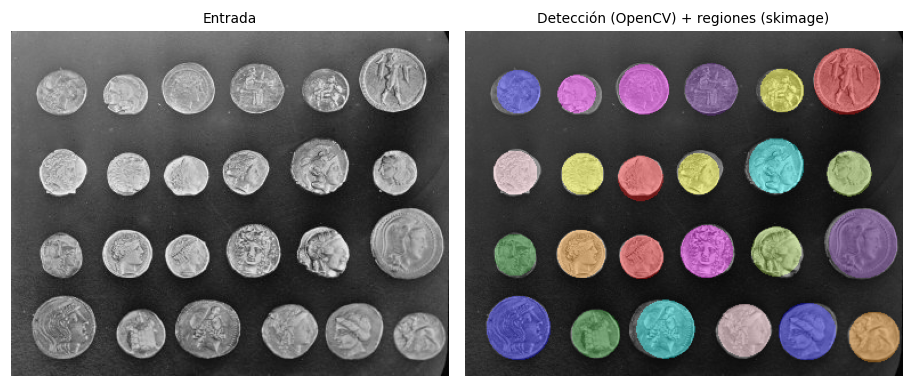

{
  "config": {
    "sigma_suavizado": 1.5,
    "hough_dp": 1.0,
    "hough_dist_min": 25,
    "hough_param1": 100,
    "hough_param2": 20,
    "radio_min": 12,
    "radio_max": 32
  },
  "versiones": {
    "python": "3.13.15",
    "opencv": "4.14.0",
    "scikit-image": "0.25.2",
    "numpy": "2.1.3"
  },
  "monedas_detectadas": 24
}


In [32]:
CONFIG = {"sigma_suavizado": 1.5, "hough_dp": 1.0, "hough_dist_min": 25, "hough_param1": 100,  # Diccionario maestro de configuración: sigma de filtro, resolución del acumulador dp, distancia mínima entre centros y umbral de Canny param_1.
          "hough_param2": 20, "radio_min": 12, "radio_max": 32}  # Umbral de votos del acumulador param_2 y rango de búsqueda radial (12 a 32 píxeles).

class ContadorMonedas:  # Define la clase modular que encapsula el pipeline de inspección de monedas.
    def __init__(self, config): self.cfg = dict(config)  # Constructor de la clase: almacena una copia inmutable de los hiperparámetros declarados.

    def verificar(self, img):  # Método de validación defensiva de precondiciones de entrada.
        assert img.dtype == np.uint8, f"se esperaba uint8 y llegó {img.dtype}"  # Aserción: rechaza cualquier entrada que no sea entera de 8 bits sin signo (`uint8`).
        if img.ndim == 3:  # Si la imagen es tridimensional (color multicanal).
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)  # Convierte de RGB a escala de grises de 1 canal como convención del pipeline.
        return img  # Retorna la imagen monocromática verificada.

    def detectar(self, gris):  # Método de detección geométrica mediante la transformada circular de Hough (OpenCV).
        c = self.cfg  # Alias local a la configuración.
        suave = cv2.GaussianBlur(gris, (0, 0), c["sigma_suavizado"])  # Suavizado gaussiano previo para atenuar grano de sensor sin desplazar los bordes circulares.
        circ = cv2.HoughCircles(suave, cv2.HOUGH_GRADIENT, dp=c["hough_dp"], minDist=c["hough_dist_min"],  # Transformada de Hough usando el método basado en gradiente `HOUGH_GRADIENT`.
                                param1=c["hough_param1"], param2=c["hough_param2"], minRadius=c["radio_min"], maxRadius=c["radio_max"])  # Pasa los parámetros de umbral de acumulador y radios de búsqueda.
        return np.zeros((0, 3)) if circ is None else circ[0]  # Retorna matriz de círculos detectados [x, y, r] o un arreglo vacío si no hubo detecciones.

    def medir(self, gris, circulos):  # Método de extracción de propiedades morfométricas y radiométricas (scikit-image).
        etiquetas = np.zeros(gris.shape, np.int32)  # Matriz de etiquetas para colorear las regiones de cada moneda detectada.
        for i, (x, y, r) in enumerate(circulos, start=1):  # Itera sobre cada círculo geométrico [x, y, r] detectado por Hough.
            rr, cc = draw.disk((y, x), r, shape=gris.shape)  # Genera los índices de fila y columna dentro del disco circular usando la convención matricial `(fila, col) = (y, x)`.
            etiquetas[rr, cc] = i  # Asigna la etiqueta del objeto i en los píxeles interiores del disco.
        tabla = pd.DataFrame(measure.regionprops_table(etiquetas, intensity_image=gris,  # Extrae métricas tabulares enriquecidas usando `measure.regionprops_table`.
                             properties=["label", "centroid", "area", "equivalent_diameter_area", "intensity_mean", "intensity_std"]))  # Propiedades medidas: etiqueta, centroide, área, diámetro equivalente, intensidad media y desviación estándar de reflectancia.
        return etiquetas, tabla  # Retorna el mapa segmentado de regiones y la tabla de estadísticas tabulares.

    def __call__(self, img):  # Interfaz ejecutable: permite invocar la instancia como una función (`contador(img)`).
        gris = self.verificar(img)  # Fase 1: Verificación de tipo y espacio cromático.
        circulos = self.detectar(gris)  # Fase 2: Detección geométrica rápida de círculos con OpenCV.
        etiquetas, tabla = self.medir(gris, circulos)  # Fase 3: Análisis morfométrico y extracción de características con scikit-image.
        return etiquetas, tabla  # Retorna tupla final de segmentación y medidas.

contador = ContadorMonedas(CONFIG)  # Instancia el pipeline industrial con la configuración centralizada.
etiquetas, tabla_monedas = contador(monedas)  # Ejecuta el pipeline completo sobre la imagen canónica de monedas.
print(f"Monedas detectadas: {len(tabla_monedas)} (hay 24 en la imagen)")  # Comprueba que el detector localizó con éxito las 24 monedas reales sin falsos positivos.
display(tabla_monedas.head().round(1))  # Despliega las primeras filas de la tabla de medidas tabulares.
mostrar([monedas, color.label2rgb(etiquetas, image=monedas, bg_label=0, alpha=0.35)],  # Visualiza la imagen original y la superposición de máscaras segmentadas coloreadas en transparencia (`alpha=0.35`).
        ["Entrada", "Detección (OpenCV) + regiones (skimage)"], tam=4.2)  # Título descriptivo de la sinergia de ambas bibliotecas.

# Bloque de serialización y auditoría científica.
registro = {"config": CONFIG, "versiones": {"python": platform.python_version(), "opencv": cv2.__version__,  # Diccionario con metadatos: hiperparámetros, versión del runtime de Python, OpenCV, skimage y NumPy.
            "scikit-image": skimage.__version__, "numpy": np.__version__}, "monedas_detectadas": int(len(tabla_monedas))}  # Registro del conteo numérico total obtenido.
json.dump(registro, open("registro_pipeline_monedas.json", "w"), indent=2)  # Exporta el manifiesto de reproducibilidad en archivo JSON con sangría de 2 espacios.
tabla_monedas.to_csv("monedas_medidas.csv", index=False)  # Exporta las medidas geométricas y radiométricas de cada moneda en un archivo CSV tabular.
print(json.dumps(registro, indent=2))  # Imprime el informe JSON en consola para verificación inmediata.

### 6.4 Validar con varias condiciones, no con una foto
Un error frecuente es ajustar un algoritmo hasta que funciona perfecto con la imagen de prueba. Comparamos dos pipelines ante perturbaciones realistas:

- **A. Segmentación afinada a mano:** Otsu + watershed sobre el gradiente + separación por distancia, con parámetros ajustados sobre la imagen original.
- **B. El pipeline de 6.3:** usa conocimiento de la forma (las monedas son círculos).

,A. segmentación afinada,B. Hough + regionprops
condición,,
original,24.00,24.0
más oscura (×0.6),28.00,24.0
más brillante,24.00,24.0
gamma 1.6,27.00,24.0
ruido σ=12,27.00,24.0
rotada 90°,24.00,24.0
desenfocada,23.00,24.0
luz en rampa,27.00,24.0
error absoluto medio,1.75,0.0


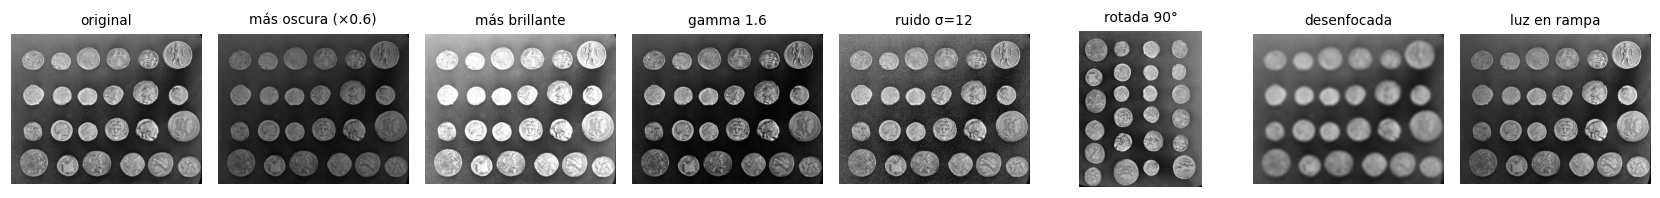

In [33]:
def pipeline_segmentacion(img):  # Pipeline alternativo basado puramente en morfología matemática, gradientes y transformada de Watershed.
    g = img if img.ndim == 2 else cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)  # Asegura entrada en escala de grises.
    b = cv2.GaussianBlur(g, (0, 0), 2)  # Suavizado gaussiano previo con sigma=2.0 para atenuar ruido.
    t = filters.threshold_otsu(b)  # Umbral global de Otsu para binarización inicial.
    marcadores = np.zeros(b.shape, np.int32); marcadores[b < t * 0.7] = 1; marcadores[b > t * 1.15] = 2  # Marcadores histéricos de 3 niveles: 1 para fondo seguro (< 0.7t), 2 para moneda segura (> 1.15t) y 0 para zona de incertidumbre.
    fg = ndi.binary_fill_holes(segmentation.watershed(filters.sobel(b), marcadores) == 2)  # Segmentación de primer término con Watershed sobre el relieve de Sobel y relleno morfológico de huecos (`binary_fill_holes`).
    etq = measure.label(fg); areas = np.bincount(etq.ravel()); areas[0] = 0; fg = areas[etq] >= 300  # Filtrado de partículas espurias: descarta componentes con área menor a 300\text{ px}^2.
    d = ndi.distance_transform_edt(fg)  # Transformada de distancia euclidiana exacta sobre la máscara limpia.
    picos = peak_local_max(d, min_distance=10, labels=measure.label(fg), exclude_border=False)  # Localiza los centros individuales de cada moneda separando contactos mediante picos de distancia.
    m = np.zeros(fg.shape, np.int32); m[tuple(picos.T)] = np.arange(1, len(picos) + 1)  # Genera marcadores numerados \{1, \dots, N_{\text{picos}}\} para la segunda inundación.
    return int(segmentation.watershed(-d, m, mask=fg).max())  # Retorna el recuento final de monedas segmentadas por Watershed sobre -d.

rng = np.random.default_rng(0)  # Generador pseudoaleatorio con semilla fija 0.
condiciones = {  # Diccionario maestro con las 8 perturbaciones físicas y fotométricas controladas.
    "original": monedas,  # Condición 1: Imagen canónica de referencia limpia.
    "más oscura (×0.6)": (monedas * 0.6).astype(np.uint8),  # Condición 2: Subexposición lumínica (atenuación al 60\% de brillo).
    "más brillante": np.clip(monedas * 1.3 + 20, 0, 255).astype(np.uint8),  # Condición 3: Sobreexposición lumínica y saturación de reflectancia.
    "gamma 1.6": (255 * (monedas / 255) ** 1.6).astype(np.uint8),  # Condición 4: Distorsión no lineal de contraste por curva de respuesta gamma.
    "ruido σ=12": np.clip(monedas + rng.normal(0, 12, monedas.shape), 0, 255).astype(np.uint8),  # Condición 5: Grano de sensor severo con ruido gaussiano aditivo de sigma=12.
    "rotada 90°": cv2.rotate(monedas, cv2.ROTATE_90_CLOCKWISE),  # Condición 6: Rotación espacial ortogonal de 90^\circ en sentido horario.
    "desenfocada": cv2.GaussianBlur(monedas, (0, 0), 2.5),  # Condición 7: Aberración óptica severa por desenfoque de lente (sigma=2.5).
    "luz en rampa": np.clip(monedas * np.linspace(0.6, 1.2, monedas.shape[1])[None], 0, 255).astype(np.uint8),  # Condición 8: Iluminación no uniforme con gradiente espacial en rampa horizontal (0.6x a 1.2x).
}  # Fin de condiciones de estrés.
filas = [{"condición": n, "A. segmentación afinada": pipeline_segmentacion(img), "B. Hough + regionprops": len(contador(img)[1])}  # Evalúa ambos pipelines sobre cada una de las 8 condiciones adversas.
         for n, img in condiciones.items()]  # Itera sobre las variantes fotométricas y geométricas.
res = pd.DataFrame(filas).set_index("condición")  # Estructura la tabla de resultados indexada por condición de prueba.
res.loc["error absoluto medio"] = (res - 24).abs().mean().round(2)  # Computa el Error Absoluto Medio (MAE) respecto al Ground Truth de 24 monedas: \text{MAE} = \frac{1}{8}\sum_{k=1}^8
display(res)  # Despliega la tabla comparativa de robustez industrial.
mostrar(list(condiciones.values()), list(condiciones), cols=8, tam=1.9)  # Cuadrícula horizontal que despliega las 8 imágenes perturbadas para inspección visual directa.

**Para discutir en clase**
1. ¿Qué parámetros del pipeline A dependen implícitamente de la imagen original? ¿Cómo los habrían detectado sin esta prueba?
2. El pipeline B funciona porque las monedas son círculos. ¿Qué conocimiento previo equivalente existe en su problema?
3. ¿Qué debería guardar un pipeline para que otra persona reproduzca exactamente sus resultados dentro de un año?